# 00 - Data Audit & Cleaning

Goal of this notebook:

1. **Load** the raw, PII-stripped reservations parquet (cached locally by `src.data_loader`).
2. **Early row filters** (§2.5-2.6)
3. **Column audit** (§3)
   - **3.0**   pre-analysis engineering
   - **3.0.5** data-quality manual drops
   - **3.1**   100%-missing (auto)
   - **3.2**   obvious leakage (auto)
   - **3.3**   id/code/name trios (manual)
   - **3.4**   near-constants (manual)
   - **3.5**   free-text / opaque-IDs (manual)
   - **3.6**   numeric multicollinearity (manual)
   - **3.7**   categorical multicollinearity (manual)
4. **Row-level cleaning** (§4)
6. **Class-imbalance decision** (§6)
7. **Point-in-time label timing** (§7)
8. **Column overview** (§8)
9. **Save** `Data/reservations_clean.parquet` (§9).
10. **Data dictionary** (§10)
11. **Feature roster export** (§11) -> `Data/feature_roster.json`
12. **Walk forward splitting**

**Contextual decisions:**

- Target : cancellation **at or before arrival** - `status == "Canceled"` AND `cancel_days_before_arrival >= 0` (positive class, encoded in §4.5). Same-day / on-arrival cancels are POSITIVE; only cancels logged *after* arrival are excluded. Rows are restricted to the **resolved** statuses `{Canceled, CheckedOut, InHouse, NoShow}`; only `Confirmed` (label not yet known) is dropped. Negatives = `CheckedOut`, `InHouse`, `NoShow`, and any `Canceled` logged after arrival. A `NoShow` is a **negative**. The guest never cancelled a future night (the hazard model treats it as a censored survivor). A no-show still frees a room operationally, so an expected-no-show term is added to the overbooking allowance *downstream* - it is not folded into this model's positive class.
- Leakage policy: any column that is only populated *after* the cancellation event is treated as leakage and dropped.


## 0 - Setup


In [1]:
# -----------------------------------------------------------------------------
# Imports - loading, styling, paths come from src/. 
# -----------------------------------------------------------------------------
from __future__ import annotations
import sys, json, warnings, time
from pathlib import Path

_t0 = time.perf_counter()
def _step(msg: str) -> None:
    print(f"  [{time.perf_counter()-_t0:5.2f}s] {msg}", flush=True)

_step("locating project root...")
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists():
    if _here == _here.parent:
        raise RuntimeError("could not find project root (no pyproject.toml above)")
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

_step("importing numpy / pandas / matplotlib / seaborn...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_step("importing helpers from src...")
from src import (
    apply_stayery_style, color, categorical_palette, diverging_triplet,
    load_brand_config, load_locations,
    load_reservations, load_clean_reservations, strip_pii, PII_COLUMNS,
    add_country_region,
    data_dir, configs_dir, figures_dir, tables_dir, schema_config_path,
)

_step("applying style / output dirs / display options...")

apply_stayery_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

FIG_DIR = figures_dir() / "00_audit"
TBL_DIR = tables_dir()  / "00_audit"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

_step("setup done.")


  [ 0.00s] locating project root...
  [ 0.00s] importing numpy / pandas / matplotlib / seaborn...
  [ 1.80s] importing helpers from src...
  [ 1.84s] applying style / output dirs / display options...
  [ 1.84s] setup done.


In [2]:
#Building audit logic and time stamps

column_decisions: dict[str, tuple[str, str, str]] = {}
audit_log: list[dict] = []
prev: tuple[int, int] | None = None


def snap(step: str, frame: pd.DataFrame, *, prev: tuple[int, int] | None = None,
         dropped_cols: list[str] | None = None) -> tuple[int, int]:
    n_rows, n_cols = frame.shape
    # Robust to a stray `prev` (e.g. the run-diff dict): only diff a real (rows, cols) tuple.
    if isinstance(prev, tuple) and len(prev) == 2:
        d_rows, d_cols = prev[0] - n_rows, prev[1] - n_cols
        delta = []
        if d_cols: delta.append(f"-{d_cols} cols")
        if d_rows: delta.append(f"-{d_rows:,} rows")
        delta_str = f"   ({', '.join(delta)})" if delta else "   (no change)"
    else:
        delta_str = ""
    print(f"  > {step:<55s}  {n_rows:>8,} rows x {n_cols:>3} cols{delta_str}")
    audit_log.append({"step": step, "rows": n_rows, "cols": n_cols,
                      "dropped_cols": list(dropped_cols or [])})
    return (n_rows, n_cols)


def record_drop(cols: list[str], reason: str, step: str) -> None:
    for c in cols:
        column_decisions[c] = ("dropped", reason, step)


def apply_manual_drops(drops: list[str], reason: str, step: str) -> None:
    global df, prev
    present      = [c for c in drops if c in df.columns]
    already_gone = [c for c in drops if c not in df.columns]
    if already_gone:
        print(f"  note: skipping (already dropped earlier): {already_gone}")
    if present:
        df = df.drop(columns=present)
        record_drop(present, reason, step)
        prev = snap(f"{step} manual drops applied", df, prev=prev, dropped_cols=present)
        print(f"  dropped: {present}")
    else:
        print(f"  no drops applied (list empty).")
        prev = snap(f"{step} manual drops (no-op)", df, prev=prev)


def reset_audit_state() -> None:
    """Wipe column_decisions / audit_log / prev so a full re-run starts clean."""
    global column_decisions, audit_log, prev
    column_decisions.clear()
    audit_log.clear()
    prev = None
    print("  audit state reset (column_decisions / audit_log / prev).")

reset_audit_state()


  audit state reset (column_decisions / audit_log / prev).


## Engineered columns

Built in §3.0 (before the §3 audit and §4 cleaning), persisted to the cleaned parquet. The full disposition of every column is in the §8 overview and the §10 data dictionary.

- **Temporal / stay:** `lead_time_days`, `los_nights`, `arrival_dow`, `arrival_month`, `is_weekend_arrival`, `stay_bucket`.
- **Money:** `gross_amount`, `gross_per_night`, `diff_gross_cancellation_fee`.
- **Log twins (linear family only):** `log_gross_amount`, `los_nights_log`, `lead_time_days_log`, `gross_per_night_log`, `diff_gross_cancellation_fee_log` - routed via `src.features.family_feature_lists`.
- **Party / context:** `adults_n`, `has_promo`, `has_corporate_code`, `has_children`, `has_group`.
- **Rate plan:** `ratePlan_category` (nonref pooled, rare -> other); `ratePlan_type` dropped in §3.7 (corr ~= 1).
- **Company:** removed entirely as **leakage** - name/linkage is entered at check-in and absent at scoring. The §3.0.c clustering and `company_name_clean` are gone; company *history* + check-in language/nationality dropped in §3.2 / §5.
- **Split metadata:** `cancel_days_before_arrival` (§3.2) and `outcome_known_date` (§7) drive the walk-forward folds - never features.

## 1 - Load reservations


PII columns are stripped inside the loader (see `src.data_loader.PII_COLUMNS`).
The cache lives in `Data/reservations_raw_no_pii.parquet`; reset it by running `uv run python main.py refresh` or `load_reservations(force_refresh=True)`.


In [3]:
df = load_reservations()
prev = snap("loaded raw parquet", df)
ORIGINAL_COLUMNS = list(df.columns)   # snapshot for the final decision table
print(f"  PII columns stripped: {len(PII_COLUMNS)}")
print(f"  arrival range: {df['arrival'].min()}  -  {df['arrival'].max()}")
print(f"  created range: {df['created'].min()}  -  {df['created'].max()}")


loading cached parquet: reservations_raw_no_pii.parquet


  > loaded raw parquet                                        216,726 rows x  73 cols
  PII columns stripped: 27
  arrival range: 2019-01-14 14:00:00+00:00  -  2027-12-26 14:00:00+00:00
  created range: 2019-01-07 13:52:18+00:00  -  2026-07-01 06:29:26+00:00


## 2 - Status distribution & target definition

The label is **cancellation at or before arrival**: `status == "Canceled"` AND
`cancel_days_before_arrival >= 0` (computed in §3.2, encoded in §4.5). **Same-day /
on-arrival cancels are POSITIVE** - they are real signal. Only cancels logged
*after* arrival (cdba < 0) are excluded. No-shows are **negatives** (the guest
never cancelled). Rows stay restricted to resolved statuses; only `Confirmed`
(no outcome yet) is dropped in §2.5.


Raw status counts.

| status                      | in the model | why                                                        |
|-----------------------------|--------------|------------------------------------------------------------|
| Canceled (at/before arrival, incl. same-day) | **positive** | the event we predict: `cancel_days_before_arrival >= 0` |
| Canceled (after arrival)    | negative     | logged after arrival - no future night freed pre-arrival   |
| CheckedOut                  | negative     | booking fully resolved without a pre-arrival cancel        |
| InHouse                     | negative     | guest checked in -> did not cancel before arrival          |
| NoShow                      | negative     | guest never cancelled; no pre-arrival cancel event         |
| Confirmed                   | dropped      | label not yet known - booking has not yet resolved         |

**Note on no-shows.** A no-show is *not* a cancellation - the booking is never cancelled, the guest simply doesn't arrive - so it is a **negative** for the cancel-by-arrival target (kept in §2.5, not dropped). The hazard model (08) likewise treats it as a censored survivor (it reached arrival without an event). A no-show still frees a room operationally, but with almost no lead time to resell, so the **overbooking allowance adds an expected-no-show term on top** of the cancellation forecast downstream (`E[empty] = E[cancel-before-arrival] + E[no-show]`); it is not folded into this model's positive class.

In [4]:
status_counts = df["status"].value_counts(dropna=False).to_frame("count")
status_counts["share"] = status_counts["count"] / status_counts["count"].sum()

total_share = status_counts["share"].sum()
print(f"  rows accounted for: {status_counts['count'].sum():,} / {len(df):,}")
print(f"  share total       : {total_share:.4%} ")
assert abs(total_share - 1.0) < 1e-9, "status shares do not sum to 1 - investigate"
print()
display(status_counts.style.format({"share": "{:.2%}"}))


resolved = df[df["status"].isin({"Canceled", "CheckedOut", "InHouse", "NoShow"})]
print(f"\n  resolved bookings (Canceled/CheckedOut/InHouse/NoShow): {len(resolved):,}")
print(f"  raw 'Canceled' share: {(resolved['status'] == 'Canceled').mean():.2%} "
      f"(refined to cancel-before-arrival in §4.5)")

  rows accounted for: 216,726 / 216,726
  share total       : 100.0000% 



,count,share
status,,
CheckedOut,163354,75.37%
Canceled,45383,20.94%
Confirmed,5074,2.34%
NoShow,2236,1.03%
InHouse,679,0.31%



  resolved bookings (Canceled/CheckedOut/InHouse/NoShow): 211,652
  raw 'Canceled' share: 21.44% (refined to cancel-before-arrival in §4.5)


## 2.5 - Early row filters

Keep the **resolved** statuses (`Canceled`, `CheckedOut`, `InHouse`, `NoShow`) and apply the arrival-window cutoff; drop only unresolved `Confirmed` bookings (no outcome yet). These filters simplify the column audit.
The row-level cleaning in §4 picks up again on a more granular level (duplicates, lead-time fix, outliers, tiny props, final QC).

In [5]:
# Keep every resolved booking, the label (cancel-before-arrival) is set in §4.5.
# No-shows and on/after-arrival cancels are negatives
TARGET_STATUSES = {"Canceled", "CheckedOut", "InHouse", "NoShow"}
before_status = df["status"].value_counts(dropna=False).to_dict()

n_before = len(df)
df = df[df["status"].isin(TARGET_STATUSES)].copy()
n_dropped = n_before - len(df)
print(f"  dropped {n_dropped:,} rows in non-resolved statuses (no outcome yet):")
for s, c in before_status.items():
    if s not in TARGET_STATUSES:
        print(f"    - {s}: {c:,}")
print(f"\n  kept Canceled / CheckedOut / InHouse / NoShow: "
      f"{(df['status']=='Canceled').sum():,} / "
      f"{(df['status']=='CheckedOut').sum():,} / "
      f"{(df['status']=='InHouse').sum():,} / "
      f"{(df['status']=='NoShow').sum():,}")
prev = snap("2.5 kept resolved statuses (Canceled+CheckedOut+InHouse+NoShow)", df, prev=prev)


  dropped 5,074 rows in non-resolved statuses (no outcome yet):
    - Confirmed: 5,074

  kept Canceled / CheckedOut / InHouse / NoShow: 45,383 / 163,354 / 679 / 2,236
  > 2.5 kept resolved statuses (Canceled+CheckedOut+InHouse+NoShow)   211,652 rows x  73 cols   (-5,074 rows)


## 2.6 - Arrival window (historical floor + future cutoff)

Two bounds are applied to `arrival`:

- **Floor** `ARRIVAL_FLOOR = 2022-08-01`: everything earlier is the COVID time or times where not many locations where open (mass cancellations, flexible-rate surges. See the development over time in `experiments/cancellation_rate_over_time`). I am assumin an entirely different distribution which would make the model very unreliable.
- **Future cutoff** `ARRIVAL_CUTOFF = today - GRACE_DAYS`: bookings arriving on/after this are outcome-not-yet-established and dropped. The grace window protects against in-flight check-ins / late-cancel reflections not yet in the source table, and avoids the recent-window selection bias (only quick-resolving bookings would otherwise survive). In the same experiment file you can see that reducing the grace period further would not be the best idea. Set to **2 days** - the experiment confirmed a 2-day grace is enough.

In [6]:
# the cutoff is run-date-dependent, so ARRIVAL_FLOOR / ARRIVAL_CUTOFF / RUN_TIMESTAMP are stamped into Data/reservations_clean_meta.json in section 9 for reproducibility.
ARRIVAL_FLOOR  = pd.Timestamp("2022-08-01", tz="UTC")
GRACE_DAYS     = 2
RUN_TIMESTAMP  = pd.to_datetime(df["created"], utc=True).max()   # DATA-anchored "now" (extraction), not wall-clock -> reproduzierbar
ARRIVAL_CUTOFF = (RUN_TIMESTAMP.normalize() - pd.Timedelta(days=GRACE_DAYS))

n_floor = int((df["arrival"] < ARRIVAL_FLOOR).sum())
df = df[df["arrival"] >= ARRIVAL_FLOOR].copy()
print(f"  ARRIVAL_FLOOR  = {ARRIVAL_FLOOR.date()} (exclude pre-recovery / COVID regime)")
print(f"  dropped {n_floor:,} rows with arrival < {ARRIVAL_FLOOR.date()}")
prev = snap("2.6 dropped pre-floor (COVID-era) arrivals", df, prev=prev)

n_future = int((df["arrival"] >= ARRIVAL_CUTOFF).sum())
df = df[df["arrival"] < ARRIVAL_CUTOFF].copy()
print(f"  ARRIVAL_CUTOFF = {ARRIVAL_CUTOFF.date()} (today - {GRACE_DAYS} days, dynamic)")
print(f"  dropped {n_future:,} rows with arrival >= {ARRIVAL_CUTOFF.date()}")
prev = snap("2.6 dropped future arrivals", df, prev=prev)

  ARRIVAL_FLOOR  = 2022-08-01 (exclude pre-recovery / COVID regime)
  dropped 28,630 rows with arrival < 2022-08-01
  > 2.6 dropped pre-floor (COVID-era) arrivals                183,022 rows x  73 cols   (-28,630 rows)
  ARRIVAL_CUTOFF = 2026-06-28 (today - 2 days, dynamic)
  dropped 1,866 rows with arrival >= 2026-06-28
  > 2.6 dropped future arrivals                               181,156 rows x  73 cols   (-1,866 rows)


## 3 - Column-level audit

- **3.0**   pre-analysis engineering
- **3.0.5** data-quality manual drops
- **3.1**   100%-missing columns -> **auto-drop**
- **3.2**   obvious leakage columns -> **auto-drop**
- **3.3**   duplicate-information trios (id / code / name) -> inspect + manual drop
- **3.4**   near-constant / single-value columns -> inspect + manual drop
- **3.5**   free-text / description columns -> inspect + manual drop
- **3.6**   numeric multicollinearity (Spearman heatmap) -> inspect + manual drop
- **3.7**   categorical association (Cramer's V) -> inspect + manual drop

### 3.0 - Pre-analysis engineering
 
- **a - Channel merging:** `ChannelManager` rows take the real OTA from `source` (-> Booking.com / Expedia / Airbnb / ...), rename map applied.
- **b - Dates:** `los_nights`, `lead_time_days`.
- **d - Rate plan:** `ratePlan_type` (coarse), `ratePlan_category` (nonref pooled, rare < 50 -> `other`), `is_nonref` (binary)
- **e - Group flag:** `has_group`.
- **f - Cancellation economics:** `diff_gross_cancellation_fee`.
- **g - Party / context flags:** `adults_n`, `has_promo`, `has_corporate_code`, `has_children`, `is_international`, `guest_country_region`
- **h - Calendar:** `arrival_dow`, `arrival_month`, `is_weekend_arrival`, `stay_bucket`.
- **i - Money tail:** `log_gross_amount`.
- **j - Cleanup:** drop raw columns now subsumed by the engineered ones.


In [7]:
# ---- 3.0.a - Channel merging --------------------------------------------
if "source" in df.columns and "channelCode" in df.columns:
    chan = df["channelCode"].astype("string")
    src  = df["source"].astype("string")
    mask = (chan == "ChannelManager") & src.notna() & (src.str.len() > 0)
    n_subs = int(mask.sum())
    df.loc[mask, "channelCode"] = src[mask]
    df = df.drop(columns=["source"])
    record_drop(["source"], "merged into channelCode (3.0)", "3.0")
    print(f"  substituted {n_subs:,} 'ChannelManager' rows with the source value, "
          f"then dropped source.")
    print(f"  channelCode values: {sorted(df['channelCode'].dropna().unique().tolist())}")


  substituted 111,321 'ChannelManager' rows with the source value, then dropped source.
  channelCode values: ['Airbnb', 'Apartmentservice', 'Booking.com', 'CRC Corporate Rates Club', 'Direct', 'Expedia', 'Expedia Affiliate Network', 'GDS', 'HRS', 'HomeLike', 'HousingAnywhere', 'Ibe', 'Other', 'Rydoo', 'SilverDoor', 'Synxis', 'Tomas', 'TravelPerk', 'ehotel AG', 'feratel']


In [8]:
# OTA rename cleaning.

CHANNEL_RENAME = {
    "BookingCom":                "Booking.com",
    "Expedia Affiliate Network": "Expedia",
}
df["channelCode"] = df["channelCode"].astype("string").replace(CHANNEL_RENAME)

print(f"  channelCode rename applied: {CHANNEL_RENAME}")
print(f"  final channelCode distribution ({df['channelCode'].nunique()} levels):")
print(df["channelCode"].value_counts(dropna=False).to_string())


  channelCode rename applied: {'BookingCom': 'Booking.com', 'Expedia Affiliate Network': 'Expedia'}
  final channelCode distribution (19 levels):
channelCode
Booking.com                 82377
Ibe                         46082
Direct                      23753
HRS                         11839
Expedia                      7743
Airbnb                       6692
Synxis                       1008
CRC Corporate Rates Club      707
Rydoo                         298
Other                         242
GDS                           188
TravelPerk                    123
feratel                        48
HomeLike                       36
Tomas                          11
Apartmentservice                4
SilverDoor                      3
ehotel AG                       1
HousingAnywhere                 1


In [9]:
# ---- 3.0.b - LOS + lead_time --------------------------------
arr_ts = pd.to_datetime(df["arrival"],   utc=True)
dep_ts = pd.to_datetime(df["departure"], utc=True)
crt_ts = pd.to_datetime(df["created"],   utc=True)

df["lead_time_days"] = (arr_ts - crt_ts) / pd.Timedelta(days=1)
df["los_nights"]     = ((dep_ts.dt.normalize() - arr_ts.dt.normalize())
                        / pd.Timedelta(days=1)).astype("Int64")

df["gross_amount"]    = pd.to_numeric(df["totalGrossAmount_amount"], errors="coerce")
df["gross_per_night"] = df["gross_amount"] / df["los_nights"].replace(0, pd.NA)


In [10]:
# ---- 3.0.d - Rate-plan classification (type / category / is_nonref) ------------
import re

NONREF_RE = re.compile(
    r"\bnon[_\-\s]*ref|\bnrf\b|\bprepaid\b|nicht.*erstatt|non.*erstatt",
    flags=re.IGNORECASE,
)
PROMO_KEYWORDS = ("special", "promo", "stay again",
                  "family & friends", "opening", "-%", "%")
MIN_CATEGORY_COUNT = 50 


def _classify_rate_plan(raw) -> tuple[str, int, str]:
    if raw is None or pd.isna(raw):
        return "", 0, "unknown"
    n = re.sub(r"\s+", " ", str(raw).strip().lower())
    if not n:
        return "", 0, "unknown"
    is_nf = bool(NONREF_RE.search(n))
    if is_nf:
        t = "nonref"
    elif n == "comp" or n.startswith("comp "):
        t = "comp"
    elif ("corporate" in n or "firmenrate" in n
          or "consortia" in n or "hrs" in n):
        t = "corporate"
    elif any(k in n for k in PROMO_KEYWORDS):
        t = "promo"
    elif ("flexible" in n or "midstay" in n or "shortstay" in n
          or "longstay" in n or "airbnb" in n):
        t = "flexible"
    else:
        t = "other"
    return n, int(is_nf), t


if {"ratePlan_type", "ratePlan_category", "is_nonref"}.issubset(df.columns):
    print("  ratePlan_type / ratePlan_category / is_nonref already present - re-using.")
elif "ratePlan_name" in df.columns:
    raw     = df["ratePlan_name"].astype("string")
    uniques = raw.dropna().unique().tolist()
    lookup  = {u: _classify_rate_plan(u) for u in uniques}

    norm_map = {u: v[0] for u, v in lookup.items()}
    nref_map = {u: v[1] for u, v in lookup.items()}
    type_map = {u: v[2] for u, v in lookup.items()}

    df["ratePlan_name"] = raw.map(norm_map).fillna("").astype("string")
    df["is_nonref"]     = raw.map(nref_map).fillna(0).astype("Int64")
    df["ratePlan_type"] = raw.map(type_map).fillna("unknown").astype("string")

    cat = df["ratePlan_name"].where(df["ratePlan_name"].str.len() > 0, "unknown")
    cat = cat.mask(df["is_nonref"] == 1, "nonref")
    _arr      = pd.to_datetime(df["arrival"], utc=True)
    # Rare-bucket collapse fit on past only data 
    _train_m  = _arr < (_arr.max() - pd.Timedelta(days=28))
    counts    = cat[_train_m].value_counts()
    protected = {"nonref", "unknown", "other"}
    small     = counts[counts < MIN_CATEGORY_COUNT].index.difference(protected)
    df["ratePlan_category"] = cat.where(~cat.isin(small), "other").astype("string")
else:
    for col, dt in [("ratePlan_name",     "string"),
                    ("ratePlan_category", "string"),
                    ("ratePlan_type",     "string"),
                    ("is_nonref",         "Int64")]:
        df[col] = pd.Series(pd.NA, index=df.index, dtype=dt)

print(f"  is_nonref:         {int(df['is_nonref'].sum()):,} rows "
      f"({df['is_nonref'].mean():.1%})")
print(f"  ratePlan_category: {df['ratePlan_category'].nunique()} unique buckets")
print(f"  ratePlan_type breakdown:")
for k, v in df["ratePlan_type"].value_counts().items():
    print(f"    {k:<12s} {v:>8,}  ({v / len(df):.1%})")

other_audit = (df.loc[df["ratePlan_type"] == "other", "ratePlan_name"]
                 .value_counts().head(30))
if len(other_audit):
    print(f"\n  top {len(other_audit)} names in 'other' bucket "
          "(extend _classify_rate_plan if you want these grouped):")
    display(other_audit)

# --- Persist the (normalized ratePlan_name -> ratePlan_category) map ----------
if {"ratePlan_name", "ratePlan_category"}.issubset(df.columns):
    RATEPLAN_CATEGORY_MAP = (
        df[["ratePlan_name", "ratePlan_category"]].dropna()
          .drop_duplicates("ratePlan_name")
          .set_index("ratePlan_name")["ratePlan_category"].astype(str).to_dict()
    )
    print(f"  ratePlan_category map persisted: {len(RATEPLAN_CATEGORY_MAP)} "
          f"normalized-name -> category entries")

  is_nonref:         32,683 rows (18.0%)
  ratePlan_category: 39 unique buckets
  ratePlan_type breakdown:
    flexible      122,609  (67.7%)
    nonref         32,683  (18.0%)
    corporate      23,269  (12.8%)
    comp            1,711  (0.9%)
    promo             820  (0.5%)
    other              64  (0.0%)

  top 4 names in 'other' bucket (extend _classify_rate_plan if you want these grouped):


ratePlan_name
long stay channels    36
guv rate              20
fair discount          7
home office            1
Name: count, dtype: int64[pyarrow]

  ratePlan_category map persisted: 79 normalized-name -> category entries


In [11]:
# ---- 3.0.e - has_group ------------------------------------------------
if "has_group" in df.columns:
    print(f"  has_group already present ({int(df['has_group'].sum()):,} flagged) - re-using.")
else:
    block = (df["blockId"].astype("string") if "blockId" in df.columns
             else pd.Series(pd.NA, index=df.index, dtype="string"))
    gname = (df["groupName"].astype("string") if "groupName" in df.columns
             else pd.Series(pd.NA, index=df.index, dtype="string"))
    df["has_group"] = ((block.fillna("").str.len() > 0) |
                       (gname.fillna("").str.len() > 0)).astype("Int64")
    print(f"  has_group: {int(df['has_group'].sum()):,} rows flagged "
          f"({df['has_group'].mean():.1%} of frame)")


  has_group: 9,152 rows flagged (5.1% of frame)


In [12]:
# ---- 3.0.f - diff_gross_cancellation_fee ------------------------------
if "diff_gross_cancellation_fee" in df.columns:
    print(f"  diff_gross_cancellation_fee already present "
          f"({df['diff_gross_cancellation_fee'].notna().sum():,} non-null) - re-using.")
elif "cancellationFee_fee_amount" in df.columns:
    cf = pd.to_numeric(df["cancellationFee_fee_amount"], errors="coerce")
    df["diff_gross_cancellation_fee"] = df["gross_amount"] - cf
    print(f"  diff_gross_cancellation_fee: "
          f"{df['diff_gross_cancellation_fee'].notna().sum():,} non-null")
else:
    df["diff_gross_cancellation_fee"] = pd.Series(pd.NA, index=df.index, dtype="Float64")
    print("  cancellationFee_fee_amount missing - diff_gross_cancellation_fee = NaN")


  diff_gross_cancellation_fee: 181,156 non-null


In [13]:
# ---- 3.0.g - Party / context flags ------------------------------------
def _to_str_nz(s, idx):
    if s is None:
        return pd.Series([""] * len(idx), index=idx, dtype="string")
    return s.astype("string").fillna("")

if "adults" in df.columns and "adults_n" not in df.columns:
    df["adults_n"] = pd.to_numeric(df["adults"], errors="coerce").astype("Int64")

country = _to_str_nz(df.get("primaryGuest_address_countryCode"), df.index)
df["is_international"]   = (country != "DE").astype("Int64")
df["has_promo"]          = (_to_str_nz(df.get("promoCode"),     df.index).str.len() > 0).astype("Int64")
df["has_corporate_code"] = (_to_str_nz(df.get("corporateCode"), df.index).str.len() > 0).astype("Int64")
df["has_children"]       = ((pd.to_numeric(df.get("children"), errors="coerce").fillna(0) > 0) |
                            (_to_str_nz(df.get("childrenAges"), df.index).str.len() > 0)).astype("Int64")
df = add_country_region(df)   # structural region collapse of countryCode (src/features.py)
print("  built: adults_n, is_international, guest_country_region, has_promo, has_corporate_code, has_children")


  built: adults_n, is_international, guest_country_region, has_promo, has_corporate_code, has_children


In [14]:
# ---- 3.0.h - Calendar features (arrival_dow / month / weekend / stay_bucket) ----
arr = pd.to_datetime(df["arrival"], utc=True)
df["arrival_dow"]        = arr.dt.dayofweek.astype("Int64")
df["arrival_month"]      = arr.dt.month.astype("Int64")
df["is_weekend_arrival"] = (arr.dt.dayofweek >= 5).astype("Int64")

# `los_nights` exists already (§3.0.b). Coarse three-way bucket: short / mid / long.
los = df["los_nights"].astype("Int64")
_los_top = max(int(los.max()) if pd.notna(los.max()) else 200, 7)  # guard: bins must be monotonic even if max<=6
df["stay_bucket"] = pd.cut(
    los,
    bins=[-1, 2, 6, _los_top],
    labels=["short", "mid", "long"],
).astype("string")
print(f"  built calendar features. "
      f"dow range {df['arrival_dow'].min()}..{df['arrival_dow'].max()}, "
      f"month range {df['arrival_month'].min()}..{df['arrival_month'].max()}, "
      f"weekend share {df['is_weekend_arrival'].mean():.1%}, "
      f"stay_bucket counts: {df['stay_bucket'].value_counts().to_dict()}")


  built calendar features. dow range 0..6, month range 1..12, weekend share 25.3%, stay_bucket counts: {'short': 120818, 'mid': 38032, 'long': 22306}


In [15]:
# ---- 3.0.i - Log transforms ---------------------------------------
for _base, _log in [("gross_amount",                "log_gross_amount"),
                    ("los_nights",                  "los_nights_log"),
                    ("lead_time_days",              "lead_time_days_log"),
                    ("gross_per_night",             "gross_per_night_log"),
                    ("diff_gross_cancellation_fee", "diff_gross_cancellation_fee_log")]:
    if _base in df.columns:
        df[_log] = np.log1p(pd.to_numeric(df[_base], errors="coerce").clip(lower=0))
print("  log twins built:", [c for c in df.columns if c.endswith("_log")])

  log twins built: ['los_nights_log', 'lead_time_days_log', 'gross_per_night_log', 'diff_gross_cancellation_fee_log']


In [16]:
# ---- 3.0.j - Drop raw columns now subsumed by engineered features -------
SUBSUMED_AFTER_ENG: list[str] = [
    "promoCode",                   # -> has_promo
    "corporateCode",               # -> has_corporate_code
    "adults",                      # -> adults_n
    "booker_company_name",         # -> company_name_combined
    "primaryGuest_company_name",   # -> company_name_combined
    "cancellationFee_dueDateTime", # feature removed raw col still dropped
]
present = [c for c in SUBSUMED_AFTER_ENG if c in df.columns]
if present:
    df = df.drop(columns=present)
    record_drop(present, "subsumed by engineered feature (§3.0.j)", "3.0.j")
    prev = snap("3.0.j dropped subsumed raws", df, prev=prev, dropped_cols=present)
    print(f"  dropped: {present}")
else:
    print("  no subsumed raws to drop.")


  > 3.0.j dropped subsumed raws                               181,156 rows x  90 cols   (--17 cols)
  dropped: ['promoCode', 'corporateCode', 'adults', 'booker_company_name', 'primaryGuest_company_name', 'cancellationFee_dueDateTime']


### 3.0.5 - Data-quality manual drops



| group                                | columns                                                                                                  | why                                                                                                       |
|--------------------------------------|----------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| Payment account                      | `paymentAccount_paymentMethod`, `paymentAccount_isVirtual`, `paymentAccount_isActive`                    | known to be **inaccurate** in the source - data-quality issue, not a real feature.                        |
| Balance                              | `balance_amount`, `balance_currency`                                                                     | post-event signal (zeros out after refund / invoicing) - we treat as data quality + leakage and drop it.  |
| Guest-history flags                  | `is_first_res`, `is_last_res`                                                                            | not accurate at this point in time?                 |
| Unit-level identifiers               | `unit_id`, `unit_name`, `unit_description`, `unit_unitGroupId`                                           | unit assignment is operational, often re-shuffled after booking; not a stable predictor. |
| Group / company                      | `blockId`, `groupName`, `company_id`                                                                     | `has_group` (§3.0.e) captures the group signal; ALL company columns are leakage (entered at check-in, absent at scoring) - dropped here + in §3.2, no company clustering. |

`unitGroup_name` survives §3.0.5 and is later resolved against the rest of the `unitGroup_*` trio in §3.3 / §3.4. Company data is dropped entirely as leakage (no `company_name_clean`).


In [17]:
# § 3.0.5 - manual data-quality drops.
MANUAL_DROPS_DATA_QUALITY: list[str] = [
    "paymentAccount_paymentMethod",
    "paymentAccount_isVirtual",
    "paymentAccount_isActive",
    "balance_amount",
    "balance_currency",
    "is_first_res",
    "is_last_res",
    "unit_id",
    "unit_name",
    "unit_description",
    "unit_unitGroupId",
    "blockId",            # subsumed by has_group (§3.0.e); raw col dropped to avoid leakage of group dynamics
    "company_id",         # raw company linkage - leakage (entered at check-in, absent at scoring)
    "groupName",          # also subsumed by has_group (§3.0.e); free-text
    "noShowFee_fee_amount",
]
apply_manual_drops(MANUAL_DROPS_DATA_QUALITY,
                   reason="manual: data-quality issue (§ 3.0.5)",
                   step="3.0.5")


  > 3.0.5 manual drops applied                                181,156 rows x  75 cols   (-15 cols)
  dropped: ['paymentAccount_paymentMethod', 'paymentAccount_isVirtual', 'paymentAccount_isActive', 'balance_amount', 'balance_currency', 'is_first_res', 'is_last_res', 'unit_id', 'unit_name', 'unit_description', 'unit_unitGroupId', 'blockId', 'company_id', 'groupName', 'noShowFee_fee_amount']


### 3.1 - Drop 100%-missing columns


In [18]:
n = len(df)
miss = (pd.DataFrame({"n_missing": df.isna().sum(),
                      "rate":      df.isna().sum() / n})
        .sort_values("rate", ascending=False))
display(miss[miss["rate"] >= 0.001].head(30).style.format({"rate": "{:.2%}"}))

fully_missing = miss[miss["rate"] >= 0.999].index.tolist()
print(f"\n  fully-missing columns to drop: {fully_missing}")
df = df.drop(columns=fully_missing)
record_drop(fully_missing, "100% missing", "3.1")
prev = snap("3.1 dropped 100%-missing columns", df, prev=prev, dropped_cols=fully_missing)


,n_missing,rate
company_name,181156,100.00%
company_code,181156,100.00%
commission_before_amount,181156,100.00%
commission_currency,181156,100.00%
commission_amount,181156,100.00%
company_canCheckOutOnAr,181156,100.00%
commission_before_currency,181156,100.00%
children,179306,98.98%
childrenAges,179306,98.98%
cancellationTime,143764,79.36%



  fully-missing columns to drop: ['company_name', 'company_code', 'commission_before_amount', 'commission_currency', 'commission_amount', 'company_canCheckOutOnAr', 'commission_before_currency']
  > 3.1 dropped 100%-missing columns                          181,156 rows x  68 cols   (-7 cols)


### 3.2 - Drop obvious leakage columns


A column is **leakage** if its value is only set *after* the cancellation event, or if it directly encodes the target. Cancel timing is captured once as `cancel_days_before_arrival` (in the §3.2 code, *before* `cancellationTime` is dropped) and kept as target/split metadata only - never a model feature.

| column                       | why it leaks                                                                                          |
|------------------------------|-------------------------------------------------------------------------------------------------------|
| `modified`                   | timestamp of the last status change - for a Canceled booking that *is* the cancellation timestamp.    |
| `allFoliosHaveInvoice`       | only set once the stay is invoiced; impossible at booking time.                                       |
| `guest_id`                   | post-hoc guest dedup key; not available at booking time in the live scoring path.                     |
| `commission_*` (amount/currency) | commission settles post-stay - redundant and irrelevant at booking time. |
| `cancellationTime` | exists only for *cancelled* bookings = direct label-timing leakage. Captured once as `cancel_days_before_arrival` (kept as metadata) **before** the drop; the hazard model (08) reads that clean column - it no longer touches raw. |
| `travelPurpose`, `primaryGuest_address_countryCode`, `primaryGuest_preferredLanguage`, `guest_country_region`, `is_international` | nationality / language / purpose are entered at/around **check-in**, blank on upcoming bookings. |
| `company_name`, `company_code`, `company_canCheckOutOnAr` | company linkage is populated at check-in and absent at scoring and depends highly on OTA |


In [19]:
# Target-side cancel timing
_arr_ct = pd.to_datetime(df["arrival"], utc=True)
_ct_raw = pd.to_datetime(df["cancellationTime"], utc=True, errors="coerce")
df["cancel_days_before_arrival"] = (_arr_ct - _ct_raw) / pd.Timedelta(days=1)

LEAKAGE = [
    # post-event / target-side (only set after the booking resolves)
    "modified",
    "cancellationTime",              # timing already captured as cancel_days_before_arrival (above)
    "allFoliosHaveInvoice",
    "guest_id",
    "commission_amount", "commission_before_amount",
    "commission_currency", "commission_before_currency",
    # check-in leakage: nationality / language / purpose entered at check-in,
    # blank on not-yet-arrived bookings -> model would learn "blank => cancel"
    "travelPurpose",
    "primaryGuest_address_countryCode", "primaryGuest_preferredLanguage",
    "guest_country_region", "is_international",
    # company linkage: entered at check-in, absent at scoring time (whole block leaks)
    "company_name", "company_code", "company_canCheckOutOnAr",
]
present = [c for c in LEAKAGE if c in df.columns]
df = df.drop(columns=present)
record_drop(present, "leakage (post-event signal)", "3.2")
prev = snap("3.2 dropped leakage columns", df, prev=prev, dropped_cols=present)
print(f"\n  dropped: {present}")


  > 3.2 dropped leakage columns                               181,156 rows x  60 cols   (-8 cols)

  dropped: ['modified', 'cancellationTime', 'allFoliosHaveInvoice', 'guest_id', 'travelPurpose', 'primaryGuest_address_countryCode', 'primaryGuest_preferredLanguage', 'guest_country_region', 'is_international']


### 3.3 - Inspect duplicate-information trios


For each entity (property, ratePlan, unitGroup, cancellationFee), the source table provides three columns carrying *similar* information: an opaque internal ID, a short business code, and a human-readable name.


In [20]:
def _sample_values(s: pd.Series, n: int = 4) -> str:
    """Return up to `n` distinct values as a comma-separated string."""
    vals = (s.dropna().astype("string").drop_duplicates().head(n).tolist())
    out = ", ".join(repr(v) for v in vals)
    extra = int(s.nunique(dropna=True)) - len(vals)
    if extra > 0:
        out += f", … (+{extra} more)"
    return out


TRIOS = {
    "property":         ["property_code", "property_id", "property_name"],
    "ratePlan":         ["ratePlan_name", "ratePlan_code", "ratePlan_id"],
    "unitGroup":        ["unitGroup_code", "unitGroup_name", "unitGroup_id"],
    "cancellationFee":  ["cancellationFee_name", "cancellationFee_code", "cancellationFee_id"],
}

trio_summary_rows = []
for label, members in TRIOS.items():
    for m in members:
        if m not in df.columns:
            continue
        s = df[m]
        trio_summary_rows.append({
            "trio":           label,
            "column":         m,
            "n_missing":      int(s.isna().sum()),
            "n_unique":       int(s.nunique(dropna=True)),
            "sample_values":  _sample_values(s),
        })

trio_tbl = pd.DataFrame(trio_summary_rows).set_index(["trio", "column"])
display(
    trio_tbl.style
        .background_gradient(cmap="YlGnBu", subset=["n_unique"])
        .background_gradient(cmap="YlOrRd", subset=["n_missing"])
)
print("\n  trio inspection complete - drops (if any) are applied in the next cell.")
prev = snap("3.3 inspected trios", df, prev=prev)



  trio inspection complete - drops (if any) are applied in the next cell.
  > 3.3 inspected trios                                       181,156 rows x  60 cols   (no change)


**§ 3.3 manual drop placeholder.** Look at the trio table above. Type any columns you want to remove into the list. Empty list = no-op.


In [21]:
# § 3.3 - manual drops for duplicate-info trios.
MANUAL_DROPS_TRIOS: list[str] = [
    "property_id",
    "property_code",
    "ratePlan_code",
    "ratePlan_id",
    "ratePlan_name", # here I drop all because we have categories now
    "unitGroup_code",
    "unitGroup_id",
    "cancellationFee_code",
    "cancellationFee_id"
]
apply_manual_drops(MANUAL_DROPS_TRIOS,
                   reason="manual: trio duplicate-info (§ 3.3)",
                   step="3.3")


  > 3.3 manual drops applied                                  181,156 rows x  51 cols   (-9 cols)
  dropped: ['property_id', 'property_code', 'ratePlan_code', 'ratePlan_id', 'ratePlan_name', 'unitGroup_code', 'unitGroup_id', 'cancellationFee_code', 'cancellationFee_id']


### 3.4 - Inspect near-constant columns


Single-valued (`n_unique == 1`) or near-constant columns typically carry no predictive information

The first table lists every candidate with its dominant value and that value's share. The second table breaks down the full normalised distribution for columns where `n_unique > 1`. Decide and apply in the manual-drop cell that follows.


In [22]:
# All columns where the dominant value covers ≥ 97% of non-NaN rows are flagged as "near-constant candidates"
NEAR_CONSTANT_THRESHOLD = 0.97

candidates = []
for c in df.columns:
    s = df[c]
    if s.notna().sum() == 0:
        continue
    top_share = float(s.value_counts(normalize=True, dropna=True).iloc[0])
    if top_share >= NEAR_CONSTANT_THRESHOLD:
        candidates.append(c)

# Summary table.
report = pd.DataFrame({
    "column":    candidates,
    "n_unique":  [int(df[c].nunique(dropna=True)) for c in candidates],
    "top_value": [df[c].mode(dropna=True).iloc[0] if df[c].notna().any() else "<all NaN>"
                  for c in candidates],
    "top_share": [float(df[c].value_counts(dropna=True, normalize=True).iloc[0])
                  if df[c].notna().any() else float("nan")
                  for c in candidates],
})
print(f"  near-constant candidates (≥{NEAR_CONSTANT_THRESHOLD:.0%} of non-NaN rows "
      f"in the dominant value): {len(candidates)}")
display(report.set_index("column").style.format({"top_share": "{:.1%}"}))

# Full normalised distribution for the candidates with n_unique > 1.
multi_val = [c for c in candidates if int(df[c].nunique(dropna=True)) > 1]
if multi_val:
    print(f"\n  value distribution for the {len(multi_val)} candidates with n_unique > 1:")
    dist_rows = []
    for c in multi_val:
        vc = df[c].value_counts(dropna=False, normalize=True)
        for val, share in vc.items():
            dist_rows.append({
                "column": c,
                "value":  "<NaN>" if pd.isna(val) else val,
                "share":  share,
                "count":  int(df[c].eq(val).sum()) if not pd.isna(val) else int(df[c].isna().sum()),
            })
    dist_tbl = (pd.DataFrame(dist_rows)
                  .set_index(["column", "value"])
                  .sort_values(["column", "share"], ascending=[True, False]))
    display(dist_tbl.style.format({"share": "{:.2%}"})
                          .background_gradient(cmap="YlOrRd", subset=["share"]))
else:
    print("  (every candidate is single-valued - no distribution to show)")

prev = snap("3.4 inspected near-constants", df, prev=prev)


  near-constant candidates (≥97% of non-NaN rows in the dominant value): 9


,n_unique,top_value,top_share
column,,,
unitGroup_type,1,BedRoom,100.0%
totalGrossAmount_currency,1,EUR,100.0%
children,2,1,99.9%
cancellationFee_fee_currency,1,EUR,100.0%
noShowFee_code,1,NONREF,100.0%
noShowFee_name,1,No-Show Fee,100.0%
noShowFee_description,1,The no-show fee varies based on the length of stay and origin of the booking.,100.0%
noShowFee_fee_currency,1,EUR,100.0%
has_children,2,0,99.0%



  value distribution for the 2 candidates with n_unique > 1:


  > 3.4 inspected near-constants                              181,156 rows x  51 cols   (no change)


**§ 3.4 manual drop placeholder.** Decide which near-constant columns to dropbased on the tables above. Empty list = no-op.


In [23]:
# § 3.4 - manual drops for near-constant columns.
MANUAL_DROPS_NEAR_CONSTANT: list[str] = [
   "unitGroup_type",
   "totalGrossAmount_currency",
   "cancellationFee_fee_currency",
   "noShowFee_fee_currency",
   "noShowFee_name",
   "noShowFee_code",
   "children",
   "childrenAges"
]
apply_manual_drops(MANUAL_DROPS_NEAR_CONSTANT,
                   reason="manual: near-constant (§ 3.4)",
                   step="3.4")


  > 3.4 manual drops applied                                  181,156 rows x  43 cols   (-8 cols)
  dropped: ['unitGroup_type', 'totalGrossAmount_currency', 'cancellationFee_fee_currency', 'noShowFee_fee_currency', 'noShowFee_name', 'noShowFee_code', 'children', 'childrenAges']


### 3.5 - Inspect free-text / opaque-ID columns


The table below lists every column that looks like *free text* (its name ends in `_description`) or an *opaque identifier* (high cardinality + opaque strings) that isn't already a kept feature. 

`n_unique` close to the row count is a strong hint that the column is a per-row ID without structure (and so unlikely to generalise as a feature).

In [24]:
description_cols = [c for c in df.columns if c.endswith("_description")]

# Opaque-ID candidates: columns whose distinct-value count is close to the
# row count (≥ 50% of rows distinct) nd whose dtype is string-like.
opaque_candidates = []
for c in df.columns:
    if c in description_cols:
        continue
    s = df[c]
    if s.dtype.kind not in ("O", "U", "S") and str(s.dtype) not in ("string",):
        continue
    nunique = int(s.nunique(dropna=True))
    if nunique == 0:
        continue
    if nunique / max(len(s), 1) >= 0.5:
        opaque_candidates.append(c)

candidates = sorted(set(description_cols + opaque_candidates))
candidates = [c for c in candidates if c in df.columns]

if candidates:
    report = pd.DataFrame({
        "column":        candidates,
        "kind":          ["description" if c in description_cols else "opaque-ID-like"
                          for c in candidates],
        "n_unique":      [int(df[c].nunique(dropna=True)) for c in candidates],
        "n_missing":     [int(df[c].isna().sum()) for c in candidates],
        "sample_values": [_sample_values(df[c], n=3) for c in candidates],
    })
    display(report.set_index("column"))
else:
    print("  no free-text or opaque-ID candidates found.")

prev = snap("3.5 inspected free-text / opaque-ID columns", df, prev=prev)


,kind,n_unique,n_missing,sample_values
column,,,,
bookingId,opaque-ID-like,152909,0,"'SQTLDGDQ', 'LQHUYPSS', 'PRATIOOI', … (+152906..."
cancellationFee_description,description,27,0,'Airbnb cancellation policy for Longstay.\nFul...
id,opaque-ID-like,181156,0,"'SQTLDGDQ-1', 'LQHUYPSS-1', 'PRATIOOI-1', … (+..."
noShowFee_description,description,1,0,'The no-show fee varies based on the length of...
ratePlan_description,description,63,0,"'Only bookable via Airbnb', 'Only bookable via..."
unitGroup_description,description,27,0,'22 m² Apartment &nbsp&nbsp|&nbsp&nbsp1.40 m D...


  > 3.5 inspected free-text / opaque-ID columns               181,156 rows x  43 cols   (no change)


**§ 3.5 manual drop placeholder.** Type any free-text or opaque-ID columns you want to remove. Empty list = no-op.


In [25]:
# § 3.5 - manual drops for free-text / opaque-ID columns.
MANUAL_DROPS_FREETEXT: list[str] = [
   "bookingId",
   "cancellationFee_description",
   "noShowFee_description",
   "ratePlan_description",
   "unitGroup_description",
   # id is dropped later - needed for dedup
]
apply_manual_drops(MANUAL_DROPS_FREETEXT,
                   reason="manual: free-text / opaque ID (§ 3.5)",
                   step="3.5")


  > 3.5 manual drops applied                                  181,156 rows x  38 cols   (-5 cols)
  dropped: ['bookingId', 'cancellationFee_description', 'noShowFee_description', 'ratePlan_description', 'unitGroup_description']


### 3.6 - Numeric multicollinearity (Spearman)


Spearman rank-correlation matrix over every kept numeric column (including `gross_amount` and the timestamp-derived numerics engineered in § 3.0). The cell prints the top 15 absolute pairs and writes every pair with `|ρ| ≥ 0.80` to `tables/00_audit/high_corr_pairs.csv` for the modelling notebooks to pick up as a VIF starting list.

Use the heatmap, the top-pairs list, and the CSV to decide what to drop. **VIF should still be computed in the modelling notebooks** (01–04) before fitting any linear or NN model.


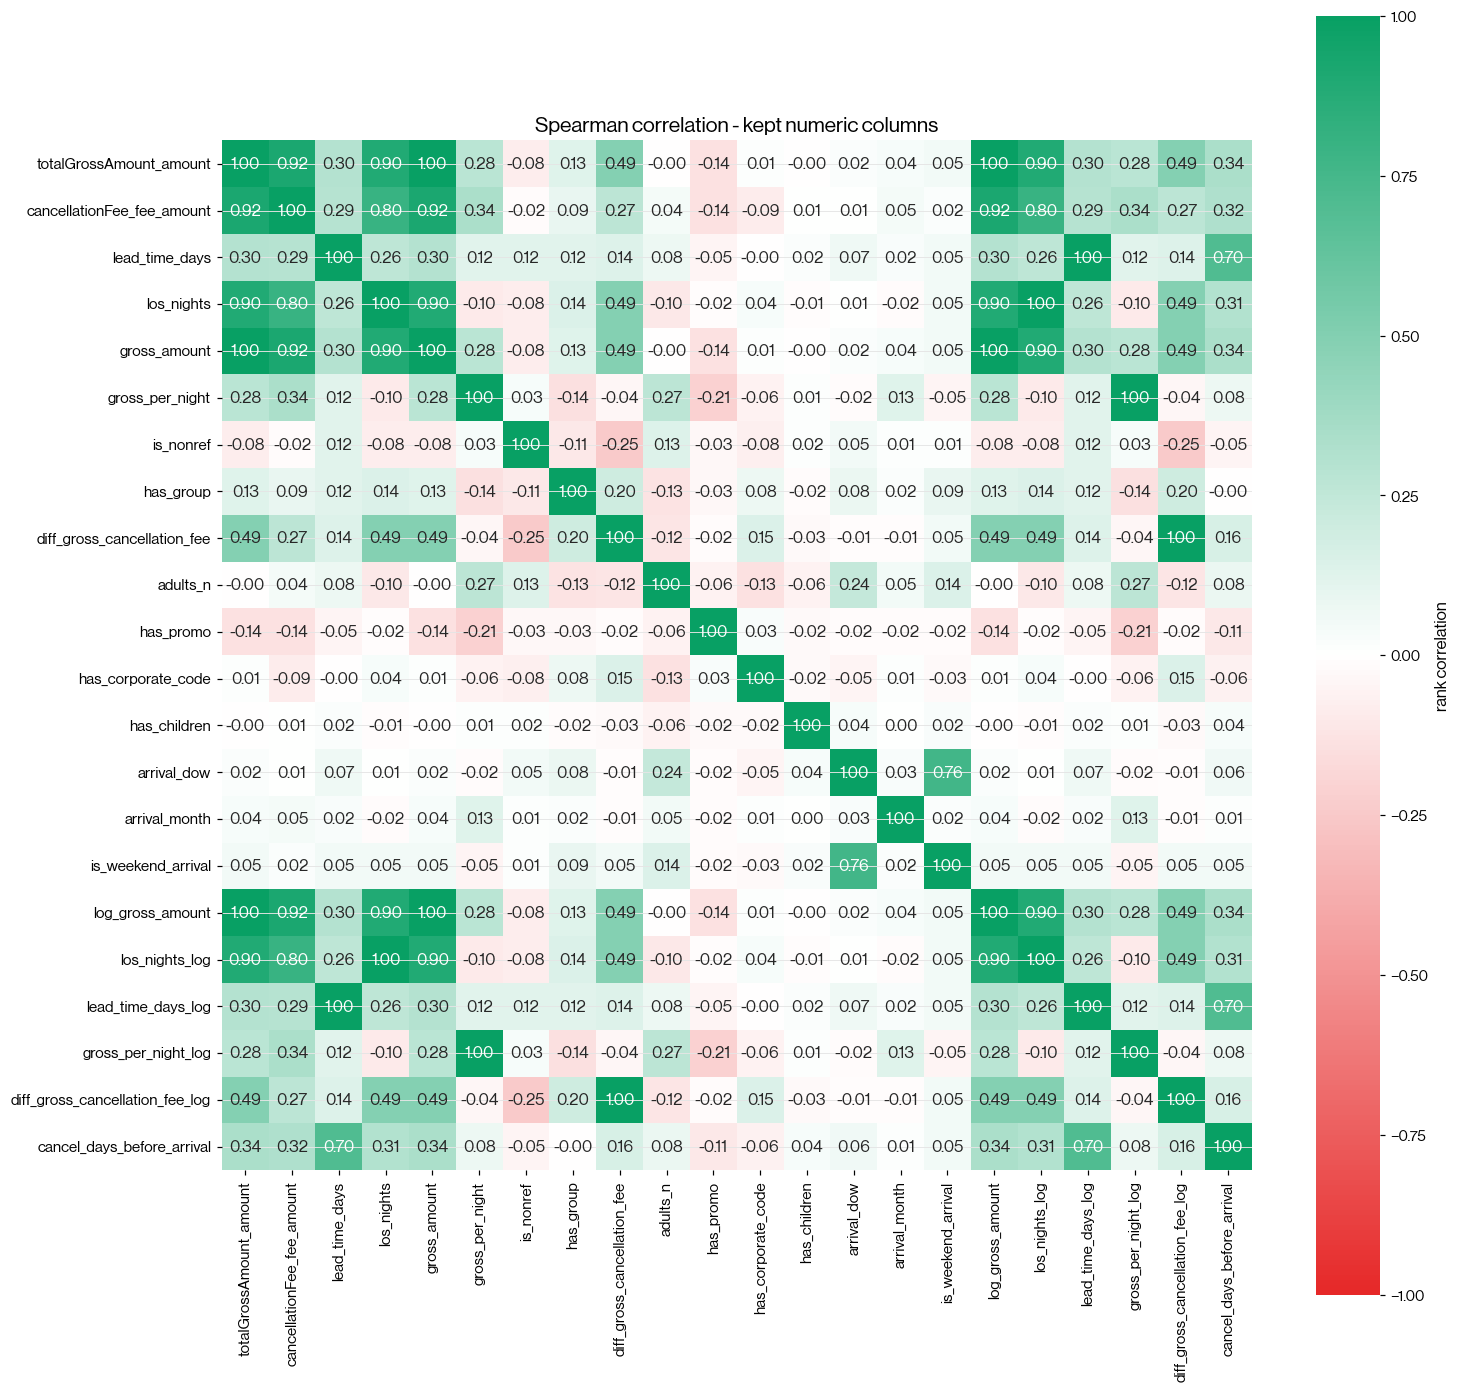


Highest |Spearman| pairs (top 15):
los_nights                       los_nights_log                     1.00
gross_per_night                  gross_per_night_log                1.00
diff_gross_cancellation_fee_log  diff_gross_cancellation_fee        1.00
lead_time_days                   lead_time_days_log                 1.00
cancellationFee_fee_amount       totalGrossAmount_amount            0.92
los_nights                       gross_amount                       0.90
                                 cancellationFee_fee_amount         0.80
is_weekend_arrival               arrival_dow                        0.76
cancel_days_before_arrival       lead_time_days_log                 0.70
lead_time_days                   cancel_days_before_arrival         0.70
gross_amount                     diff_gross_cancellation_fee_log    0.49
totalGrossAmount_amount          diff_gross_cancellation_fee        0.49
diff_gross_cancellation_fee_log  los_nights                         0.49
los_nights     

,feature_a,feature_b,abs_spearman,note
0,los_nights,los_nights_log,1.000000,identical (engineered duplicate)
1,gross_per_night,gross_per_night_log,1.000000,identical (engineered duplicate)
2,diff_gross_cancellation_fee_log,diff_gross_cancellation_fee,1.000000,identical (engineered duplicate)
3,lead_time_days,lead_time_days_log,0.999955,identical (engineered duplicate)
4,cancellationFee_fee_amount,totalGrossAmount_amount,0.921106,real collinearity - VIF check downstream
5,los_nights,gross_amount,0.898313,real collinearity - VIF check downstream


  > 3.6 inspected numeric correlations                        181,156 rows x  38 cols   (no change)


In [26]:
# `lead_time_days`, `los_nights`, `gross_amount`, `gross_per_night` were engineered in § 3.0 so they appear here alongside the raw numerics.
num_df = df.select_dtypes(include=["number"]).apply(pd.to_numeric, errors="coerce")
num_df = num_df.loc[:, num_df.nunique(dropna=True) > 1]
corr = num_df.corr(method="spearman", min_periods=50)

neg, neu, pos = diverging_triplet()
cmap = sns.blend_palette([neg, neu, pos], as_cmap=True)
fig, ax = plt.subplots(figsize=(0.55 * len(corr) + 3, 0.55 * len(corr) + 3))
sns.heatmap(corr, vmin=-1, vmax=1, cmap=cmap, annot=True, fmt=".2f",
            square=True, ax=ax, cbar_kws={"label": "rank correlation"})
ax.set_title("Spearman correlation - kept numeric columns")
fig.savefig(FIG_DIR / "05_correlation_heatmap.png"); plt.show()

stacked = (corr.where(~np.eye(len(corr), dtype=bool))
               .stack().abs().sort_values(ascending=False))
top_pairs = stacked.drop_duplicates().head(15).round(2)
print("\nHighest |Spearman| pairs (top 15):")
print(top_pairs)

# Save a CSV of high-correlation pairs so the modelling notebooks have a
# ready-made suspect list for VIF.
HIGH_CORR_THRESHOLD = 0.80
high = (stacked[stacked >= HIGH_CORR_THRESHOLD]
        .drop_duplicates()
        .rename("abs_spearman")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
high["note"] = high.apply(
    lambda r: ("identical (engineered duplicate)" if r["abs_spearman"] >= 0.999
               else "real collinearity - VIF check downstream"),
    axis=1,
)
high.to_csv(TBL_DIR / "high_corr_pairs.csv", index=False)
print(f"\n  high-correlation pairs (|ρ| ≥ {HIGH_CORR_THRESHOLD}) saved → "
      f"{TBL_DIR / 'high_corr_pairs.csv'}")
display(high)

prev = snap("3.6 inspected numeric correlations", df, prev=prev)


**§ 3.6 manual drop placeholder.** Decide which numeric columns to drop based on the heatmap, the top-pairs list, and the saved CSV. Empty list = no-op.


In [27]:
# § 3.6 - manual drops for numeric multicollinearity.
MANUAL_DROPS_NUMERIC_CORR: list[str] = [
   "totalGrossAmount_amount",     # modelled via engineered gross_amount
   "cancellationFee_fee_amount",  # captured by diff_gross_cancellation_fee
]

apply_manual_drops(MANUAL_DROPS_NUMERIC_CORR,
                   reason="manual: numeric multicollinearity (§ 3.6)",
                   step="3.6")


  > 3.6 manual drops applied                                  181,156 rows x  36 cols   (-2 cols)
  dropped: ['totalGrossAmount_amount', 'cancellationFee_fee_amount']


### 3.6.5 - Numeric ↔ categorical association (correlation ratio η)

Spearman (§3.6) is numeric↔numeric and Cramér's V (§3.7) is categorical↔categorical. The **correlation ratio** η ∈ [0,1] does: the share of a numeric's variance explained by the grouping (η≈1 ⇒ the category determines the numeric → redundant). Used here to check whether `diff_gross_cancellation_fee` is already captured by the rate plan.

In [28]:
def correlation_ratio(cats: pd.Series, vals: pd.Series) -> float:
    """Eta: sqrt(SS_between / SS_total) for a numeric grouped by a category."""
    vals = pd.to_numeric(vals, errors="coerce")
    cats = cats.astype("string")
    m = cats.notna() & vals.notna()
    cats, vals = cats[m], vals[m]
    if cats.nunique() < 2 or len(vals) < 3:
        return np.nan
    grand = vals.mean()
    ss_total = float(((vals - grand) ** 2).sum())
    if ss_total == 0:
        return np.nan
    ss_between = float(sum(len(g) * (g.mean() - grand) ** 2
                          for _, g in vals.groupby(cats, observed=True)))
    return float(np.sqrt(ss_between / ss_total))

_num = [c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c]) and c not in {"status"}]
_cat = [c for c in df.columns
        if (df[c].dtype == "string" or df[c].dtype == object)
        and 2 <= df[c].nunique(dropna=True) <= 60]
eta = pd.DataFrame({cat: {num: correlation_ratio(df[cat], df[num]) for num in _num}
                    for cat in _cat})
print("correlation ratio \u03b7  (rows = numeric, cols = categorical):")
display(eta.style.background_gradient(cmap="Reds", vmin=0, vmax=1).format("{:.2f}"))

# focused check: is diff_gross_cancellation_fee already explained by the rate plan?
for cc in ("ratePlan_type", "ratePlan_category"):
    if cc in df.columns and "diff_gross_cancellation_fee" in df.columns:
        print(f"  eta({cc} -> diff_gross_cancellation_fee) = "
              f"{correlation_ratio(df[cc], df['diff_gross_cancellation_fee']):.3f}")
if {"diff_gross_cancellation_fee", "ratePlan_type"}.issubset(df.columns):
    print("\n  diff_gross_cancellation_fee mean by ratePlan_type:")
    print(df.groupby("ratePlan_type", observed=True)["diff_gross_cancellation_fee"]
            .mean().round(1).to_string())

correlation ratio η  (rows = numeric, cols = categorical):


,status,property_name,unitGroup_name,channelCode,guaranteeType,cancellationFee_name,noShowFee_id,ratePlan_type,ratePlan_category,stay_bucket
ratePlan_isSubjectToCityTax,0.04,0.79,0.18,0.26,0.32,0.35,0.79,0.14,0.53,0.12
hasCityTax,0.13,0.85,0.25,0.22,0.19,0.25,0.85,0.23,0.37,0.10
lead_time_days,0.20,0.18,0.03,0.10,0.05,0.16,0.18,0.06,0.15,0.16
los_nights,0.17,0.18,0.10,0.23,0.11,0.74,0.18,0.14,0.75,0.63
gross_amount,0.17,0.22,0.12,0.20,0.11,0.71,0.22,0.15,0.73,0.66
gross_per_night,0.07,0.35,0.23,0.19,0.06,0.34,0.35,0.27,0.37,0.19
is_nonref,0.20,0.17,0.05,0.24,0.99,0.99,0.17,1.00,1.00,0.18
has_group,0.07,0.17,0.09,0.59,0.13,0.39,0.17,0.11,0.25,0.22
diff_gross_cancellation_fee,0.15,0.15,0.10,0.21,0.11,0.67,0.15,0.13,0.69,0.54
adults_n,0.03,0.22,0.15,0.28,0.18,0.27,0.22,0.23,0.29,0.11


  eta(ratePlan_type -> diff_gross_cancellation_fee) = 0.127
  eta(ratePlan_category -> diff_gross_cancellation_fee) = 0.692

  diff_gross_cancellation_fee mean by ratePlan_type:
ratePlan_type
comp            0.6
corporate     126.9
flexible      224.8
nonref          5.7
other        1603.0
promo          57.9


### 3.7 - Categorical association (Cramér's V)


  categorical columns analysed (21): ['status', 'property_name', 'ratePlan_isSubjectToCityTax', 'unitGroup_name', 'channelCode', 'guaranteeType', 'cancellationFee_name', 'noShowFee_id', 'hasCityTax', 'is_nonref', 'ratePlan_type', 'ratePlan_category', 'has_group', 'adults_n', 'has_promo', 'has_corporate_code', 'has_children', 'arrival_dow', 'arrival_month', 'is_weekend_arrival', 'stay_bucket']


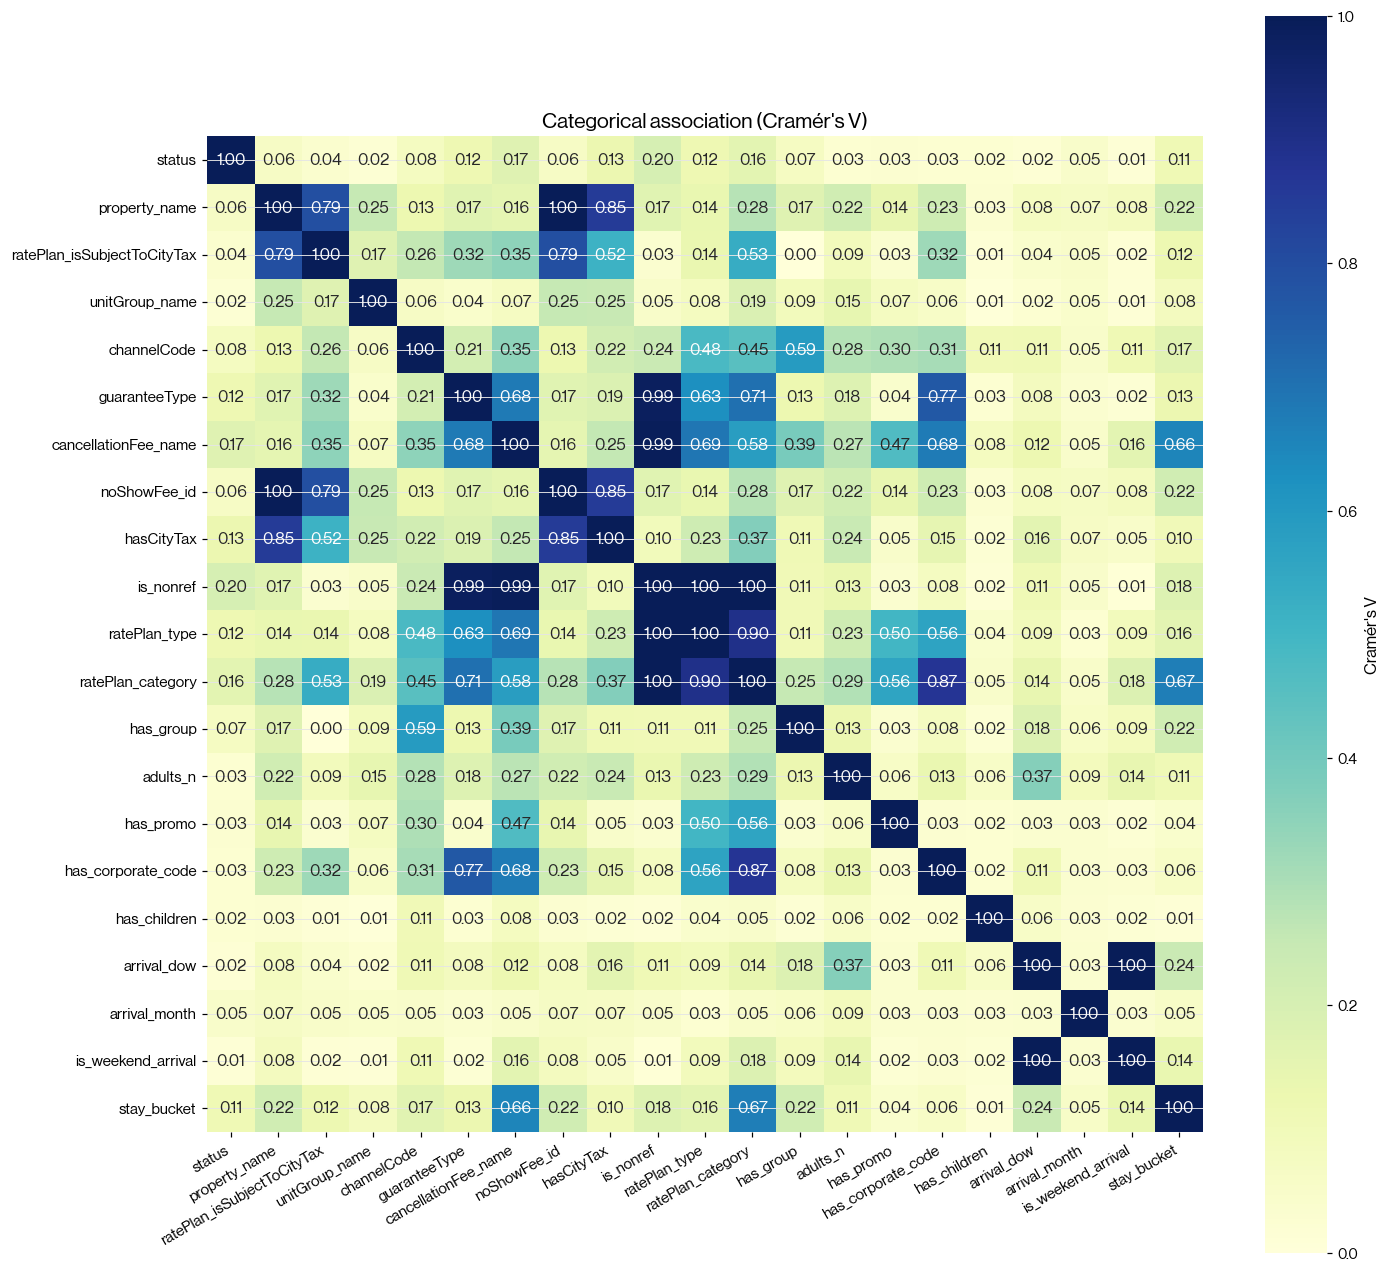


Highest Cramér's V pairs (top 15):
noShowFee_id                 property_name                  1.00
ratePlan_type                is_nonref                      1.00
is_weekend_arrival           arrival_dow                    1.00
is_nonref                    ratePlan_category              1.00
                             cancellationFee_name           0.99
                             guaranteeType                  0.99
ratePlan_category            ratePlan_type                  0.90
                             has_corporate_code             0.87
noShowFee_id                 hasCityTax                     0.85
ratePlan_isSubjectToCityTax  property_name                  0.79
noShowFee_id                 ratePlan_isSubjectToCityTax    0.79
guaranteeType                has_corporate_code             0.77
                             ratePlan_category              0.71
ratePlan_type                cancellationFee_name           0.69
cancellationFee_name         guaranteeType            

In [29]:
def chi2_stat(table: pd.DataFrame) -> float:
    observed   = table.values.astype(float)
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    grand      = observed.sum()
    if grand == 0:
        return 0.0
    expected = row_totals @ col_totals / grand
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.where(expected > 0, (observed - expected) ** 2 / expected, 0).sum()
    return float(chi2)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    if table.size == 0:
        return float("nan")
    chi2 = chi2_stat(table)
    n = table.values.sum()
    if n == 0:
        return float("nan")
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else float("nan")


DATETIME_LIKE = ("arrival", "departure", "created", "modified")
cat_candidates = []
for c in df.columns:
    if c in DATETIME_LIKE:
        continue
    s = df[c]
    nunique = int(s.nunique(dropna=True))
    if 2 <= nunique <= 50 and s.notna().mean() >= 0.5:
        cat_candidates.append(c)

print(f"  categorical columns analysed ({len(cat_candidates)}): {cat_candidates}")
assert cat_candidates, "Cramér's V still has no categorical columns - something is off with df"

cv = pd.DataFrame(index=cat_candidates, columns=cat_candidates, dtype=float)
for a in cat_candidates:
    for b in cat_candidates:
        if a == b:
            cv.loc[a, b] = 1.0
        elif not pd.isna(cv.loc[b, a]):
            cv.loc[a, b] = cv.loc[b, a]
        else:
            cv.loc[a, b] = cramers_v(df[a].astype("string"), df[b].astype("string"))

fig, ax = plt.subplots(figsize=(0.6 * len(cv) + 2, 0.6 * len(cv) + 2))
sns.heatmap(cv.astype(float), vmin=0, vmax=1, cmap="YlGnBu", annot=True,
            fmt=".2f", square=True, ax=ax, cbar_kws={"label": "Cramér's V"})
ax.set_title("Categorical association (Cramér's V)")
plt.xticks(rotation=30, ha="right")
fig.savefig(FIG_DIR / "06_cramers_v.png"); plt.show()

# Print the top off-diagonal pairs so we don't miss subtle duplications.
mask = ~np.eye(len(cv), dtype=bool)
pairs = (cv.where(mask).stack().sort_values(ascending=False)
           .drop_duplicates().head(15).round(2))
print("\nHighest Cramér's V pairs (top 15):")
print(pairs)

prev = snap("3.7 inspected categorical associations", df, prev=prev)


**§ 3.7 manual drop placeholder.** Decide which categorical columns to drop based on the Cramér's V heatmap and the top-pairs list. Empty list = no-op.


In [30]:
# § 3.7 - manual drops for categorical multicollinearity.
MANUAL_DROPS_CATEGORICAL: list[str] = [
    "noShowFee_id",
    "is_nonref",
    "hasCityTax",        
    "ratePlan_type",   
]
apply_manual_drops(MANUAL_DROPS_CATEGORICAL,
                   reason="manual: categorical multicollinearity (§ 3.7)",
                   step="3.7")


  > 3.7 manual drops applied                                  181,156 rows x  32 cols   (-4 cols)
  dropped: ['noShowFee_id', 'is_nonref', 'hasCityTax', 'ratePlan_type']


## 4 - Row-level cleaning (iterative, one rule at a time)

### 4.1 - Drop duplicates


Two tiers of duplicate:

- **Exact duplicates** on the booking `id` - these should be impossible by source-system contract, but we check.
- **Soft duplicates** on `(property_code, arrival, departure, gross_amount)` - usually
  the same booking re-issued under a new `id` due to a system migration. We
  keep the first occurrence (the original).


In [31]:
n_before = len(df)
n_id_dup = int(df.duplicated(subset=["id"]).sum()) if "id" in df.columns else 0
print(f"  duplicate booking IDs: {n_id_dup:,}")
if n_id_dup:
    df = df.drop_duplicates(subset=["id"], keep="first").copy()

soft_cols = [c for c in ["property_name", "arrival", "departure", "gross_amount"]
             if c in df.columns]
n_soft_dup = int(df.duplicated(subset=soft_cols, keep="first").sum())
print(f"  soft duplicates (property+arrival+departure+gross): {n_soft_dup:,}")
if n_soft_dup:
    print("    not dropping soft duplicates (legitimate multi-row bookings may match this key).")

# `id` was kept past §3.5 only so this dedup could run; drop the opaque ID now.
if "id" in df.columns:
    df = df.drop(columns=["id"])
    record_drop(["id"], "opaque ID (kept only for the §4.1 dedup)", "4.1")

prev = snap("4.1 dropped exact-ID duplicates", df, prev=prev)


  duplicate booking IDs: 0
  soft duplicates (property+arrival+departure+gross): 31,876
    not dropping soft duplicates (legitimate multi-row bookings may match this key).
  > 4.1 dropped exact-ID duplicates                           181,156 rows x  31 cols   (-1 cols)


### 4.2 - Fix lead_time < 0 (clip to zero, do not drop)


A negative lead time means `created > arrival`, which usually reflects a timezone artefact (booking placed minutes before midnight UTC for a same-day stay in CET). We treat these as same-day bookings by clipping `lead_time` to 0


In [32]:
arrival   = pd.to_datetime(df["arrival"],   utc=True)
created   = pd.to_datetime(df["created"],   utc=True)
lead      = (arrival - created) / pd.Timedelta(days=1)
mask_neg  = (lead < 0).fillna(False)
n_fixed   = int(mask_neg.sum())
df.loc[mask_neg, "created"] = arrival[mask_neg]
print(f"  clipped {n_fixed:,} rows where lead_time was negative (created := arrival).")

# Refresh the engineered derivative whose input we just mutated.
df["lead_time_days"] = (arrival - pd.to_datetime(df["created"], utc=True)) / pd.Timedelta(days=1)
print("  refreshed lead_time_days (stale after the clip above).")
prev = snap("4.2 clipped negative lead_time", df, prev=prev)


  clipped 6,319 rows where lead_time was negative (created := arrival).
  refreshed lead_time_days (stale after the clip above).
  > 4.2 clipped negative lead_time                            181,156 rows x  31 cols   (no change)


### 4.3 - Drop data errors and outliers


Each rule is applied separately so we can see what it removes.

1. `lead_time_days > 365` - drop
2. `los_nights < 1` - drop. Same calendar day for arrival and departure is mostly test booking or error?
3. `gross_amount <= 0` - **drop all** (no split, no NA-fill). Zero/negative gross is post-cancellation refund-zeroing or a staff comp / pipeline error - the booking-time price is gone either way. Dropped in one go so every model trains on the same rows.
4. `los_nights > 200` - drop. Hard cap: stays > 200 nights

Outliers are not dropped


In [33]:
# === §4.3.a - Diagnostic snapshot of every numeric column ====================
df["_los_nights"] = (
    (pd.to_datetime(df["departure"], utc=True).dt.normalize()
   - pd.to_datetime(df["arrival"],   utc=True).dt.normalize())
    / pd.Timedelta(days=1)
).astype("Float64")
df["_lead_time"] = (
    (pd.to_datetime(df["arrival"], utc=True)
   - pd.to_datetime(df["created"], utc=True))
    / pd.Timedelta(days=1)
).astype("Float64")
df["_gross"]     = pd.to_numeric(df["gross_amount"], errors="coerce")
df["_gpn"]       = df["_gross"] / df["_los_nights"].replace(0, pd.NA)

def numeric_diag(frame: pd.DataFrame, *, min_unique: int = 5) -> pd.DataFrame:
    """Per-column summary; skips binary/near-constant numerics."""
    rows = []
    for col in frame.select_dtypes(include="number").columns:
        s = pd.to_numeric(frame[col], errors="coerce")
        v = s.dropna()
        if v.empty or v.nunique() < min_unique:
            continue
        q1, q3 = v.quantile([0.25, 0.75])
        iqr    = q3 - q1
        lo_iqr, hi_iqr = q1 - 1.5*iqr, q3 + 1.5*iqr
        mu, sd = v.mean(), v.std()
        lo_3s, hi_3s = mu - 3*sd, mu + 3*sd
        p01, p99 = v.quantile([0.01, 0.99])
        rows.append({
            "column":         col,
            "n":              len(v),
            "n_miss":         int(s.isna().sum()),
            "mean":           mu,
            "std":            sd,
            "min":            v.min(),
            "p1":             p01,
            "p25":            q1,
            "p50":            v.median(),
            "p75":            q3,
            "p99":            p99,
            "max":            v.max(),
            "skew":           v.skew(),
            "n_out_iqr1.5":   int(((v < lo_iqr) | (v > hi_iqr)).sum()),
            "n_out_3sigma":   int(((v < lo_3s)  | (v > hi_3s )).sum()),
            "n_out_p1_p99":   int(((v < p01)    | (v > p99   )).sum()),
        })
    return pd.DataFrame(rows).set_index("column").sort_values("skew", ascending=False)

diag = numeric_diag(df)
print(f"  scanned {len(diag)} non-binary numeric columns over {len(df):,} rows")
print(f"  sorted by skew (heavy-tail candidates at top)\n")
display(
    diag.style.format({
        "mean": "{:.1f}", "std": "{:.1f}", "min": "{:.1f}",
        "p1": "{:.1f}",   "p25": "{:.1f}", "p50": "{:.1f}",
        "p75": "{:.1f}",  "p99": "{:.1f}", "max": "{:.1f}",
        "skew": "{:.2f}",
        "n_out_iqr1.5": "{:,}", "n_out_3sigma": "{:,}", "n_out_p1_p99": "{:,}",
    }).background_gradient(cmap="YlOrRd",
                           subset=["skew", "n_out_iqr1.5", "n_out_3sigma", "n_out_p1_p99"])
)

  scanned 17 non-binary numeric columns over 181,156 rows
  sorted by skew (heavy-tail candidates at top)



,n,n_miss,mean,std,min,p1,p25,p50,p75,p99,max,skew,n_out_iqr1.5,n_out_3sigma,n_out_p1_p99
column,,,,,,,,,,,,,,,
diff_gross_cancellation_fee,181156,0,170.3,713.6,0.0,0.0,0.0,0.0,28.0,3098.6,21251.0,9.65,"35,551","2,691","1,812"
los_nights,181156,0,4.6,11.6,0.0,1.0,1.0,2.0,3.0,56.0,304.0,8.20,"22,306","2,747","1,814"
_los_nights,181156,0,4.6,11.6,0.0,1.0,1.0,2.0,3.0,56.0,304.0,8.20,"22,306","2,747","1,814"
gross_amount,181156,0,403.5,799.8,0.0,28.5,99.8,178.0,364.0,3594.4,21720.0,7.76,"19,587","2,898","3,624"
_gross,181156,0,403.5,799.8,0.0,28.5,99.8,178.0,364.0,3594.4,21720.0,7.76,"19,587","2,898","3,624"
cancel_days_before_arrival,37392,143764,19.3,32.7,-114.0,-0.7,1.2,6.1,22.7,161.0,364.0,3.35,"3,662",858,747
lead_time_days,181156,0,25.6,38.5,0.0,0.0,2.7,11.0,32.0,191.1,490.3,3.04,"15,786","4,121","1,812"
_lead_time,181156,0,25.6,38.5,0.0,0.0,2.7,11.0,32.0,191.1,490.3,3.04,"15,786","4,121","1,812"
_gpn,181153,3,106.3,42.9,0.0,14.0,80.1,98.5,121.9,259.0,896.2,2.61,"10,043","2,772","3,591"


In [34]:
# === §4.3.b - Per-column inspector ==========================================
def inspect(col: str, *, log_x: bool = False) -> None:
    """Distribution + cut-impact table for ONE numeric column. Apply nothing."""
    s = pd.to_numeric(df[col], errors="coerce")
    v = s.dropna()
    if v.empty:
        print(f"  {col}: all-NaN, skipping")
        return

    print(f"  === {col} ===")
    print(f"    n = {len(v):,}   n_missing = {int(s.isna().sum()):,}")
    print(f"    range:  {v.min():>10.2f}  ..  {v.max():>10.2f}")
    print(f"    mean ± sd:   {v.mean():.2f} ± {v.std():.2f}")
    print(f"    median:      {v.median():.2f}")
    print(f"    skew:        {v.skew():.3f}    kurt: {v.kurtosis():.3f}\n")

    # Cut-impact table - what would each rule remove?
    q1, q3 = v.quantile([0.25, 0.75]); iqr = q3 - q1
    mu, sd = v.mean(), v.std()
    cuts = [
        ("IQR x1.5",   q1 - 1.5*iqr,  q3 + 1.5*iqr),
        ("IQR x3.0",   q1 - 3.0*iqr,  q3 + 3.0*iqr),
        ("3 sigma",    mu - 3*sd,     mu + 3*sd),
        ("3.5 sigma",  mu - 3.5*sd,   mu + 3.5*sd),
        ("p1 / p99",   v.quantile(0.01), v.quantile(0.99)),
        ("p0.5/p99.5", v.quantile(0.005), v.quantile(0.995)),
    ]
    table = []
    for name, lo, hi in cuts:
        n_lo, n_hi = int((v < lo).sum()), int((v > hi).sum())
        table.append({"rule": name, "lower": lo, "upper": hi,
                      "n_below": n_lo, "n_above": n_hi,
                      "n_drop_total": n_lo + n_hi,
                      "share_drop":   (n_lo + n_hi) / len(v)})
    display(pd.DataFrame(table).set_index("rule").style.format({
        "lower": "{:.1f}", "upper": "{:.1f}",
        "n_below": "{:,}", "n_above": "{:,}", "n_drop_total": "{:,}",
        "share_drop": "{:.2%}",
    }))

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].hist(v, bins=80, color=color("blue"), alpha=0.85)
    if log_x: axes[0].set_xscale("log")
    axes[0].set_title(f"{col} - histogram"); axes[0].set_xlabel(col)
    axes[1].boxplot(v, vert=False)
    axes[1].set_title(f"{col} - boxplot");  axes[1].set_xlabel(col)
    plt.tight_layout(); plt.show()

# Run for each column you flagged in §4.5.a. log_x=True hilft bei sehr schiefen distributions
#inspect("_lead_time")
#inspect("_los_nights")
#inspect("_gross", log_x=True)

In [35]:
# === §4.3.c - Apply rules (one at a time, with rationale + audit) ============

def apply_rule(label: str, keep_mask: pd.Series, rationale: str) -> int:
    """One rule, one drop count, one audit log entry."""
    global df, prev
    keep_mask = keep_mask.fillna(False)
    n_before = len(df)
    df = df[keep_mask].copy()
    n_drop = n_before - len(df)
    print(f"  ▸ {label}")
    print(f"      rationale : {rationale}")
    print(f"      kept      : {keep_mask.sum():>8,}")
    print(f"      dropped   : {n_drop:>8,}  ({n_drop/n_before:.2%} of pre-rule df)\n")
    prev = snap(f"4.3 after {label}", df, prev=prev, dropped_cols=[])
    return n_drop


In [36]:
# --- Rule 1: lead_time > 365 ------------------------------------------------
lead = df["_lead_time"]
apply_rule(
    "lead_time_days > 365",
    lead <= 365,
    "Booking placed >14 months before arrival is almost always a pipeline error.",
)


  ▸ lead_time_days > 365
      rationale : Booking placed >14 months before arrival is almost always a pipeline error.
      kept      :  181,143
      dropped   :       13  (0.01% of pre-rule df)

  > 4.3 after lead_time_days > 365                            181,143 rows x  35 cols   (--4 cols, -13 rows)


13

In [37]:

# --- Rule 2: los_nights < 1 (same calendar day) -----------------------------
los = df["_los_nights"]
apply_rule(
    "los_nights < 1 (same calendar day)",
    los >= 1,
    "Arrival.date() == departure.date() means zero-night stay - impossible.",)


  ▸ los_nights < 1 (same calendar day)
      rationale : Arrival.date() == departure.date() means zero-night stay - impossible.
      kept      :  181,140
      dropped   :        3  (0.00% of pre-rule df)

  > 4.3 after los_nights < 1 (same calendar day)              181,140 rows x  35 cols   (-3 rows)


3

In [38]:
# --- Rule 3: gross_amount <= 0 -> DROP ALL (no split, no NA-fill) ------------
# Zero/negative gross is post-cancellation refund-zeroing OR a staff comp /
# pipeline error - either way the booking-time price is gone. Drop them all in one
# go so every model trains on exactly the same rows (comparability).
gross = pd.to_numeric(df["gross_amount"], errors="coerce")
apply_rule(
    "gross_amount <= 0 (drop all)",
    ~gross.le(0).fillna(False),
    "Zero/negative gross = refund-zeroing or comp/pipeline error; booking-time value lost.",
)

  ▸ gross_amount <= 0 (drop all)
      rationale : Zero/negative gross = refund-zeroing or comp/pipeline error; booking-time value lost.
      kept      :  179,368
      dropped   :    1,772  (0.98% of pre-rule df)

  > 4.3 after gross_amount <= 0 (drop all)                    179,368 rows x  35 cols   (-1,772 rows)


1772

In [39]:
# --- Rule 4: los_nights > 200 -----------------------------------------------
df["_los_nights"] = (
    (pd.to_datetime(df["departure"], utc=True).dt.normalize()
   - pd.to_datetime(df["arrival"],   utc=True).dt.normalize())
    / pd.Timedelta(days=1)
).astype("Float64")
LOS_CAP = 200
apply_rule(
    f"los_nights > {LOS_CAP}",
    df["_los_nights"] <= LOS_CAP,
    f"Stays longer than {LOS_CAP} nights old extended-stay contracts, "
    f"different business case.",
)

  ▸ los_nights > 200
      rationale : Stays longer than 200 nights old extended-stay contracts, different business case.
      kept      :  179,349
      dropped   :       19  (0.01% of pre-rule df)

  > 4.3 after los_nights > 200                                179,349 rows x  35 cols   (-19 rows)


19

#### 4.3.d - Clean up diagnostic scratch columns


In [40]:
# Remove the underscore-prefixed columns 
diag_cols = [c for c in ("_los_nights", "_lead_time", "_gross", "_gpn") if c in df.columns]
if diag_cols:
    df = df.drop(columns=diag_cols)
    print(f"  removed scratch columns: {diag_cols}")
else:
    print("  no scratch columns to remove.")

if "departure" in df.columns:
    df = df.drop(columns=["departure"])
    record_drop(["departure"], "redundant after los_nights (§4.3)", "4.3")
prev = snap("4.3.d removed diagnostic scratch cols + departure", df, prev=prev)


  removed scratch columns: ['_los_nights', '_lead_time', '_gross', '_gpn']
  > 4.3.d removed diagnostic scratch cols + departure         179,349 rows x  30 cols   (-5 cols)


### 4.4 - Drop tiny properties (<50 rows)

**New-hotel path:** the `<50`-row are dropped for a clean per-property one-hot signal. Recently-opened hotels are therefore excluded from training, but remain fully **scoreable** (the model's OneHotEncoder uses `handle_unknown="ignore"`), so an unseen/new property simply gets no property-specific dummy and is predicted from its other features (lead time, rate plan, region, channel, ...).

In [41]:
MIN_ROWS_PER_PROPERTY = 50
counts = df.groupby("property_name").size().sort_values()
small = counts[counts < MIN_ROWS_PER_PROPERTY].index.tolist()
n_before = len(df)
if small:
    df = df[~df["property_name"].isin(small)].copy()
    print(f"  dropped tiny properties ({len(small)}): {small}")
else:
    print("  no tiny properties - nothing to drop.")
prev = snap("4.4 dropped tiny properties", df, prev=prev)


  no tiny properties - nothing to drop.
  > 4.4 dropped tiny properties                               179,349 rows x  30 cols   (no change)


### 4.5 - Final data-quality QC


In [42]:
qc_failures = []

TARGET_STATUSES = {"Canceled", "CheckedOut", "InHouse", "NoShow"}
bad_status = df[~df["status"].isin(TARGET_STATUSES)]
if len(bad_status):
    qc_failures.append(f"{len(bad_status)} rows in non-target status")

if (df["arrival"] >= ARRIVAL_CUTOFF).any():
    qc_failures.append("future arrivals still present")
if (df["arrival"] < ARRIVAL_FLOOR).any():
    qc_failures.append("pre-floor (COVID-era) arrivals still present")

arrival = pd.to_datetime(df["arrival"], utc=True)
created = pd.to_datetime(df["created"], utc=True)
if ((arrival - created) / pd.Timedelta(days=1) < 0).any():
    qc_failures.append("negative lead_time still present")

if df.isna().all(axis=1).any():
    qc_failures.append("fully-empty rows present")
if "property_name" not in df.columns or df["property_name"].isna().any():
    qc_failures.append("property_name missing or has NaN")

if qc_failures:
    raise AssertionError("QC failed:\n  - " + "\n  - ".join(qc_failures))
print(f"  all QC checks passed. final: {len(df):,} rows x {df.shape[1]} cols")
prev = snap("4.5 QC passed", df, prev=prev)

# --- Binary target encoding: 1 = cancel AT OR BEFORE arrival ----------------
# Positive = Canceled AND logged at/before arrival (cancel_days_before_arrival >= 0).
# Same-day / on-arrival cancels are POSITIVE (real signal); only cancels logged
# AFTER arrival (cdba < 0) are excluded. Coherent with the hazard event def (08).
cdba = pd.to_numeric(df["cancel_days_before_arrival"], errors="coerce")
is_cancel_by_arrival = df["status"].eq("Canceled") & cdba.ge(0)
n_noshow = int(df["status"].eq("NoShow").sum())
n_after  = int((df["status"].eq("Canceled") & cdba.lt(0)).sum())
df["status"] = is_cancel_by_arrival.astype("int8")
print(f"  status encoded int8 (1 = cancel at/before arrival, same-day incl.). "
      f"positive share: {df['status'].mean():.2%}")
print(f"  negatives include {n_noshow:,} no-shows and {n_after:,} after-arrival cancels.")

  all QC checks passed. final: 179,349 rows x 30 cols
  > 4.5 QC passed                                             179,349 rows x  30 cols   (no change)
  status encoded int8 (1 = cancel at/before arrival, same-day incl.). positive share: 19.81%
  negatives include 1,977 no-shows and 1,471 after-arrival cancels.


## 6 - Class imbalance - final share & decision

At ~20% positives the imbalance is mild. I do **not** resample or class-weight asboth distort the predicted probabilities, and those probabilities feed the overbooking decision directly (expected freed rooms, cost-optimal threshold). I rely on probability **calibration** + a **cost-based** operating point instead.


In [43]:
positive_share = (df["status"] == 1).mean()
print(f"  positive class share (cancel-before-arrival): {positive_share:.2%}")
print(f"  total rows         : {len(df):,}")
print(f"  positive (1) / negative (0): {(df['status']==1).sum():,} / "
      f"{(df['status']==0).sum():,}")
print("  negatives = CheckedOut + InHouse + NoShow + on/after-arrival cancels.")

print("\n  -> no resampling / no class_weight; calibrate + cost-optimal threshold (PR-AUC, Brier).")


  positive class share (cancel-before-arrival): 19.81%
  total rows         : 179,349
  positive (1) / negative (0): 35,526 / 143,823
  negatives = CheckedOut + InHouse + NoShow + on/after-arrival cancels.

  -> no resampling / no class_weight; calibrate + cost-optimal threshold (PR-AUC, Brier).


## 7 - Point-in-time label timing (`outcome_known_date`)

The split is a **single regime**: the decision-time **walk-forward** built in §12 (and `src.walkforward`). Here I only add `outcome_known_date`, when each label became known (cancellationTime for a pre-arrival cancel, else arrival) - the metadata the folds use to guarantee *train on outcomes known before the scoring date*. No static train/val/test column is written; the model notebooks
consume the walk-forward folds (pooled out-of-time predictions for reporting, a `TimeSeriesSplit` inside each fold's train for HP search + calibration).


In [44]:
# Single split regime = decision-time walk-forward (each booking tested once at its decision date)
from src import walkforward as wf
df = wf.add_outcome_known_date(df)   # cancellationTime (pre-arrival) else arrival
print(f"  outcome_known_date added | resolved range "
      f"{df['outcome_known_date'].min().date()} -> {df['outcome_known_date'].max().date()}")
prev = snap("7 outcome_known_date stamped (walk-forward is the only split; see §12)", df, prev=prev)

  outcome_known_date added | resolved range 2022-01-28 -> 2026-06-27
  > 7 outcome_known_date stamped (walk-forward is the only split; see §12)   179,349 rows x  31 cols   (--1 cols)


## 8 - Column overview (kept / engineered / dropped / leakage)

Every column from the original parquet, classified for the report. The modelling notebooks evaluate on the decision-time walk-forward folds (§12) and use only columns marked KEEP / ENGINEERED.


In [45]:
ENGINEERED = {
    # core temporal / money
    "lead_time_days", "los_nights", "arrival_dow", "arrival_month",
    "is_weekend_arrival", "stay_bucket", "gross_amount", "gross_per_night",
    # log twins
    "log_gross_amount", "los_nights_log", "lead_time_days_log",
    "gross_per_night_log", "diff_gross_cancellation_fee_log",
    # party / context
    "adults_n", "has_promo", "has_corporate_code", "has_children",
    # rate plan
    "ratePlan_category",
    # group + cancellation economics
    "has_group", "diff_gross_cancellation_fee",
    # target / split metadata
    "cancel_days_before_arrival", "outcome_known_date",
}
# Engineered earlier then dropped (documented in the overview).
ENGINEERED_DROPPED = {"is_nonref", "is_international", "company_name_combined",
                      "guest_country_region", "ratePlan_type"}

overview = []
final_cols = set(df.columns)

for col in ORIGINAL_COLUMNS:
    if col in final_cols:
        overview.append({"column": col, "decision": "KEEP",
                         "reason": "passed all audit steps", "step": "-"})
    elif col in column_decisions:
        d, r, s = column_decisions[col]
        overview.append({"column": col, "decision": d.upper(), "reason": r, "step": s})
    else:
        overview.append({"column": col, "decision": "DROPPED",
                         "reason": "uncategorized (bug - investigate)", "step": "?"})

for col in sorted(ENGINEERED):
    if col in final_cols:
        overview.append({"column": col, "decision": "ENGINEERED",
                         "reason": "built in §3.0/§5/§7", "step": "3.0/5/7"})
for col in sorted(ENGINEERED_DROPPED):
    if col not in final_cols:
        d, r, s = column_decisions.get(col, ("dropped",
                                             "engineered then dropped (see §3.7)",
                                             "3.0/3.7"))
        overview.append({"column": col,
                         "decision": "ENGINEERED -> DROPPED",
                         "reason": r, "step": s})

overview_df = pd.DataFrame(overview).set_index("column")
_missing8 = final_cols - set(overview_df.index)
assert not _missing8, f"§8 overview is missing final columns: {sorted(_missing8)}"
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(overview_df)
overview_df.to_csv(TBL_DIR / "column_decisions.csv")
print(f"\n  saved: {TBL_DIR / 'column_decisions.csv'}")
print(f"  kept columns        : {(overview_df['decision'] == 'KEEP').sum()}")
print(f"  engineered features : {(overview_df['decision'] == 'ENGINEERED').sum()}")
print(f"  dropped columns     : {(overview_df['decision'].isin(['DROPPED', 'ENGINEERED -> DROPPED'])).sum()}")


,decision,reason,step
column,,,
id,DROPPED,opaque ID (kept only for the §4.1 dedup),4.1
bookingId,DROPPED,manual: free-text / opaque ID (§ 3.5),3.5
blockId,DROPPED,manual: data-quality issue (§ 3.0.5),3.0.5
groupName,DROPPED,manual: data-quality issue (§ 3.0.5),3.0.5
status,KEEP,passed all audit steps,-
travelPurpose,DROPPED,leakage (post-event signal),3.2
source,DROPPED,merged into channelCode (3.0),3.0
property_id,DROPPED,manual: trio duplicate-info (§ 3.3),3.3
property_code,DROPPED,manual: trio duplicate-info (§ 3.3),3.3



  saved: /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/reports/tables/00_audit/column_decisions.csv
  kept columns        : 9
  engineered features : 22
  dropped columns     : 69


## 9 - Audit log + save the cleaned parquet

The model notebooks (`01_logreg` … `03_histgb`, `08_hazard`) load this file via `load_clean_reservations()` and evaluate on the decision-time **walk-forward folds** persisted in §12 (`Data/walkforward_folds.json`) - the single split regime. No random `train_test_split` and no static hold-out column.


In [46]:
log_df = pd.DataFrame(audit_log)
log_df["delta_rows"] = log_df["rows"].diff().fillna(0).astype(int)
log_df["delta_cols"] = log_df["cols"].diff().fillna(0).astype(int)
display(log_df)
log_df.to_csv(TBL_DIR / "audit_log.csv", index=False)

CLEAN_PATH = data_dir() / "reservations_clean.parquet"
df.to_parquet(CLEAN_PATH, index=False)
print(f"\n  saved: {CLEAN_PATH}")
print(f"        {len(df):,} rows × {df.shape[1]} columns")
print(f"        positive class share: {(df['status'] == 1).mean():.2%}")
print(f"        LOS range: {df['los_nights'].min():.0f} … {df['los_nights'].max():.0f} nights")
print(f"        lead-time range: {df['lead_time_days'].min():.0f} … {df['lead_time_days'].max():.0f} days")
print(f"        arrival range: {df['arrival'].min()} → {df['arrival'].max()}")

# Stamp run metadata so the (run-date-dependent) clean dataset is reproducible.
META_PATH = data_dir() / "reservations_clean_meta.json"
clean_meta = {
    "run_timestamp_utc":   str(RUN_TIMESTAMP),
    "arrival_floor":       str(ARRIVAL_FLOOR.date()),
    "arrival_cutoff":      str(ARRIVAL_CUTOFF.date()),
    "grace_days":          GRACE_DAYS,
    "n_rows":              int(len(df)),
    "n_cols":              int(df.shape[1]),
    "positive_share":      float((df["status"] == 1).mean()),
    "arrival_min":         str(df["arrival"].min()),
    "arrival_max":         str(df["arrival"].max()),
}
with open(META_PATH, "w") as fh:
    json.dump(clean_meta, fh, indent=2)
print(f"  saved run metadata -> {META_PATH.name}")


,step,rows,cols,dropped_cols,delta_rows,delta_cols
0,loaded raw parquet,216726,73,[],0,0
1,2.5 kept resolved statuses (Canceled+CheckedOu...,211652,73,[],-5074,0
2,2.6 dropped pre-floor (COVID-era) arrivals,183022,73,[],-28630,0
3,2.6 dropped future arrivals,181156,73,[],-1866,0
4,3.0.j dropped subsumed raws,181156,90,"[promoCode, corporateCode, adults, booker_comp...",0,17
5,3.0.5 manual drops applied,181156,75,"[paymentAccount_paymentMethod, paymentAccount_...",0,-15
6,3.1 dropped 100%-missing columns,181156,68,"[company_name, company_code, commission_before...",0,-7
7,3.2 dropped leakage columns,181156,60,"[modified, cancellationTime, allFoliosHaveInvo...",0,-8
8,3.3 inspected trios,181156,60,[],0,0
9,3.3 manual drops applied,181156,51,"[property_id, property_code, ratePlan_code, ra...",0,-9



  saved: /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/Data/reservations_clean.parquet
        179,349 rows × 31 columns
        positive class share: 19.81%
        LOS range: 1 … 198 nights
        lead-time range: 0 … 365 days
        arrival range: 2022-08-01 09:00:00+00:00 → 2026-06-27 16:49:23+00:00
  saved run metadata -> reservations_clean_meta.json


## 10 - Data dictionary (final frame)

One row per column actually present in `Data/reservations_clean.parquet`. Includes dtype, role (`target` / `meta` / `engineered` / `kept_raw`), a short description, and
basic stats (`n_unique`, `n_missing`, `top_3_values`). Saved to `tables/00_audit/data_dictionary.csv`.


In [47]:
# Data dictionary
COLUMN_DESCRIPTIONS: dict[str, str] = {
    # ---- target / split metadata ----
    "status": "Binary target: 1 = cancellation AT/BEFORE arrival (Canceled & cancel_days_before_arrival>=0, same-day positive); else 0 (CheckedOut/InHouse/NoShow/after-arrival cancel). Encoded in §4.5.",
    "cancel_days_before_arrival": "Target/split metadata (§3.2): (arrival - cancellationTime) in days; >=0 = cancelled at/before arrival (positive). Never a feature.",
    "outcome_known_date": "Split metadata (§7/§12): when the label became known (cancellationTime if pre-arrival cancel, else arrival). Drives the walk-forward folds.",
    "arrival": "Arrival timestamp, UTC. Metadata (walk-forward + hazard day-axis), not a feature.",
    "created": "Booking creation timestamp, UTC. Metadata; negative lead-times clipped in §4.2.",
    # ---- kept raw features ----
    "channelCode": "Booking channel; OTA names substituted from `source` in §3.0.a.",
    "guaranteeType": "Guarantee on file (CreditCard / Prepayment / Company / ...).",
    "property_name": "Property (hotel) name; kept after dropping property_id/code in §3.3.",
    "unitGroup_name": "Unit-group / room-category name.",
    "cancellationFee_name": "Human-readable cancellation-policy name.",
    "ratePlan_isSubjectToCityTax": "Raw boolean: is the rate plan subject to city tax (kept; hasCityTax dropped §3.7 as collinear).",
    "noShowFee_fee_amount": "No-show fee at booking time (94% zero, 6% a real strict-policy fee). Not collinear / not near-constant -> kept as a feature.",
    # ---- engineered: temporal / stay ----
    "lead_time_days": "Engineered (§3.0.b). (arrival - created) in days; negatives clipped to 0 in §4.2.",
    "los_nights": "Engineered (§3.0.b). (departure.date - arrival.date) in nights.",
    "arrival_dow": "Engineered (§3.0.h). Day of week of arrival (0=Mon).",
    "arrival_month": "Engineered (§3.0.h). Month of arrival (1-12).",
    "is_weekend_arrival": "Engineered (§3.0.h). 1 if arrival is Sat/Sun.",
    "stay_bucket": "Engineered (§3.0.h). short (<=2) / mid (3-6) / long (>6) nights.",
    # ---- engineered: money (+ LINEAR-only log twins, §3.0.i) ----
    "gross_amount": "Engineered (§3.0.b). Numeric totalGrossAmount; rows with gross<=0 are dropped in §4.3.",
    "gross_per_night": "Engineered (§3.0.b). gross_amount / los_nights.",
    "diff_gross_cancellation_fee": "Engineered (§3.0.f). gross_amount - cancellationFee_fee_amount (forfeit if cancelled).",
    "log_gross_amount": "Engineered (§3.0.i). log1p(gross_amount). LINEAR family; trees use gross_amount.",
    "los_nights_log": "Engineered (§3.0.i). log1p(los_nights). LINEAR-family twin.",
    "lead_time_days_log": "Engineered (§3.0.i). log1p(lead_time_days). LINEAR-family twin.",
    "gross_per_night_log": "Engineered (§3.0.i). log1p(gross_per_night). LINEAR-family twin.",
    "diff_gross_cancellation_fee_log": "Engineered (§3.0.i). log1p(diff_gross_cancellation_fee). LINEAR-family twin.",
    # ---- engineered: party / context / group / rate plan / company ----
    "adults_n": "Engineered (§3.0.g). Numeric adults.",
    "has_promo": "Engineered (§3.0.g). Any non-empty promoCode.",
    "has_corporate_code": "Engineered (§3.0.g). Any non-empty corporateCode.",
    "has_children": "Engineered (§3.0.g). 1 if children>0 or childrenAges non-empty.",
    "has_group": "Engineered (§3.0.e). blockId or groupName non-empty.",
    "ratePlan_category": "Engineered (§3.0.d). Rate-plan bucket; nonref pooled, rare -> 'other'.",
}

TARGET_COLS = {"status"}
META_COLS   = {"cancel_days_before_arrival", "outcome_known_date", "arrival", "created"}

def _classify(col: str) -> str:
    if col in TARGET_COLS: return "target"
    if col in META_COLS:   return "meta"
    if col in ENGINEERED:  return "engineered"
    return "kept_raw"

rows = []
for col in df.columns:
    s = df[col]; nonna = s.dropna()
    top3 = (nonna.astype("string").value_counts().head(3).index.tolist() if not nonna.empty else [])
    rows.append({"column": col, "dtype": str(s.dtype), "role": _classify(col),
                 "description": COLUMN_DESCRIPTIONS.get(col, "(no description)"),
                 "n_unique": int(nonna.nunique()) if not nonna.empty else 0,
                 "n_missing": int(s.isna().sum()),
                 "top_3_values": " | ".join(map(str, top3)) if top3 else ""})
data_dict = pd.DataFrame(rows).sort_values(["role", "column"]).set_index("column")

_undescribed = [c for c in df.columns if c not in COLUMN_DESCRIPTIONS]
assert not _undescribed, f"§10: columns missing from COLUMN_DESCRIPTIONS: {_undescribed}"
assert len(data_dict) == df.shape[1], "§10: data_dict rows != parquet columns"

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(data_dict)
data_dict.to_csv(TBL_DIR / "data_dictionary.csv")
print(f"\n  saved: {TBL_DIR / 'data_dictionary.csv'}")
print(f"  total columns in final parquet: {len(data_dict):,}  (all described)")
for role, n in data_dict["role"].value_counts().items():
    print(f"    {role:<12s} {n:>3}")

,dtype,role,description,n_unique,n_missing,top_3_values
column,,,,,,
adults_n,Int64,engineered,Engineered (§3.0.g). Numeric adults.,2,0,1 | 2
arrival_dow,Int64,engineered,Engineered (§3.0.h). Day of week of arrival (0=Mon).,7,0,0 | 1 | 4
arrival_month,Int64,engineered,Engineered (§3.0.h). Month of arrival (1-12).,12,0,5 | 6 | 11
diff_gross_cancellation_fee,float64,engineered,Engineered (§3.0.f). gross_amount - cancellationFee_fee_amount (forfeit if cancelled).,16356,0,0.0 | 12.0 | 14.0
diff_gross_cancellation_fee_log,float64,engineered,Engineered (§3.0.i). log1p(diff_gross_cancellation_fee). LINEAR-family twin.,15578,0,0.0 | 2.5649493574615367 | 2.70805020110221
gross_amount,float64,engineered,Engineered (§3.0.b). Numeric totalGrossAmount; rows with gross<=0 are dropped in §4.3.,29561,0,99.0 | 89.0 | 79.0
gross_per_night,Float64,engineered,Engineered (§3.0.b). gross_amount / los_nights.,27801,0,99.0 | 89.0 | 79.0
gross_per_night_log,Float64,engineered,Engineered (§3.0.i). log1p(gross_per_night). LINEAR-family twin.,27003,0,4.605170185988092 | 4.499809670330265 | 4.382026634673881
has_children,Int64,engineered,Engineered (§3.0.g). 1 if children>0 or childrenAges non-empty.,2,0,0 | 1



  saved: /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/reports/tables/00_audit/data_dictionary.csv
  total columns in final parquet: 31  (all described)
    engineered    20
    kept_raw       6
    meta           4
    target         1


## 11 - Feature roster export

The roster decision now lives in `FEATURE_EXCLUSIONS` in `src.features` (reason -> columns). This cell just derives the modelable columns from the final cleaned frame and writes `Data/feature_roster.json` (feature lists + `log_twins` for the family-specific views). Everything downstream loads it via `src.load_feature_roster()` / `src.roster_features()`.

In [48]:
# =============================================================================
# §11 FEATURE ROSTER  ->  Data/feature_roster.json   (single source of truth)
# =============================================================================
from src import model_feature_roster, excluded_columns, log_twin_map

ROSTER_NUMERIC, ROSTER_CATEGORICAL = model_feature_roster(df)
EXCLUDED = excluded_columns()                 # {column: reason} - the audit trail

# One roster, family-aware: a skewed numeric column and its _log twin both live
# in the parquet. The model notebooks pick per family via
# src.features.family_feature_lists (linear -> log twin, tree -> raw). 
LOG_TWINS = log_twin_map(ROSTER_NUMERIC)

# Dynamic (scoring-time) features are point-in-time per (booking, scoring-date),
# built in src.scoring.build_features relative to S (live = now). it is not in clean-parquet
# columns and never static features. The hazard model encodes the horizon via its
# days_until_arrival axis.
DYNAMIC_NUMERIC = ["days_until_arrival", "days_since_booking",
                   "pct_lead_time_elapsed", "is_within_7d_of_arrival"]

_leaked = set(DYNAMIC_NUMERIC) & (set(ROSTER_NUMERIC) | set(ROSTER_CATEGORICAL))
assert not _leaked, f"dynamic features leaked into the static roster: {_leaked}"
_MUST_HAVE_CAT = {"property_name", "unitGroup_name", "channelCode", "ratePlan_category",
                  "guaranteeType", "cancellationFee_name"}
_missing = _MUST_HAVE_CAT - set(ROSTER_CATEGORICAL)
assert not _missing, (f"DEGENERATE ROSTER - expected categoricals missing: {_missing}. "
                      f"Got categorical={sorted(ROSTER_CATEGORICAL)}.")
assert len(ROSTER_NUMERIC) >= 8, f"suspiciously few numeric features: {ROSTER_NUMERIC}"
print(f"  roster OK: {len(ROSTER_NUMERIC)} numeric + {len(ROSTER_CATEGORICAL)} categorical "
      f"| {len(LOG_TWINS)} log-twin pair(s)")
for _c in df.columns:
    if _c in EXCLUDED:
        continue
    _role = ("num" if _c in ROSTER_NUMERIC else "cat" if _c in ROSTER_CATEGORICAL else "DROPPED")
    print(f"    {_c:32s} dtype={str(df[_c].dtype):16s} -> {_role}")

roster = {
    "generated_by": "notebooks/00_data_audit.ipynb",
    "generated_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "clean_parquet_rows": int(len(df)),
    "clean_parquet_cols": int(df.shape[1]),
    "split": "walk_forward_arrival_anchored_H14 (§12, src.walkforward)",
    "target": "status",  # 1 = cancel before arrival (§4.5)
    "numeric": sorted(ROSTER_NUMERIC),
    "categorical": sorted(ROSTER_CATEGORICAL),
    "log_twins": LOG_TWINS,
    "dynamic_numeric": DYNAMIC_NUMERIC,
    "excluded": EXCLUDED,
    "n_numeric": len(ROSTER_NUMERIC),
    "n_categorical": len(ROSTER_CATEGORICAL),
    # Fitted serving artifact (so src reproduces training engineering by lookup):
    "ratePlan_category_map": globals().get("RATEPLAN_CATEGORY_MAP", {}),
}
ROSTER_PATH = data_dir() / "feature_roster.json"
with open(ROSTER_PATH, "w") as fh:
    json.dump(roster, fh, indent=2)

print(f"  wrote {ROSTER_PATH}")
print(f"  numeric ({len(ROSTER_NUMERIC)}):     {sorted(ROSTER_NUMERIC)}")
print(f"  categorical ({len(ROSTER_CATEGORICAL)}): {sorted(ROSTER_CATEGORICAL)}")
print(f"  log twins: {LOG_TWINS}")


  roster OK: 18 numeric + 7 categorical | 4 log-twin pair(s)
    property_name                    dtype=str              -> cat
    ratePlan_isSubjectToCityTax      dtype=boolean          -> num
    unitGroup_name                   dtype=str              -> cat
    channelCode                      dtype=string           -> cat
    guaranteeType                    dtype=str              -> cat
    cancellationFee_name             dtype=str              -> cat
    lead_time_days                   dtype=float64          -> num
    los_nights                       dtype=Int64            -> num
    gross_per_night                  dtype=Float64          -> num
    ratePlan_category                dtype=string           -> cat
    has_group                        dtype=Int64            -> num
    diff_gross_cancellation_fee      dtype=float64          -> num
    adults_n                         dtype=Int64            -> num
    has_promo                        dtype=Int64            -> num
 

## §12 Walk-forward splitting foundation + run-to-run diff

Persists the point-in-time **decision-time walk-forward** folds: each booking is tested exactly once, at its decision date `S* = max(created, arrival - H)` if still open then, scored at horizon `d = min(lead, H)`. This keeps SHORT-LEAD bookings (median lead ~11 days) that a non-overlapping arrival grid silently dropped. `outcome_known_date` is split metadata (the roster skips it). The model notebooks pool the per-fold out-of-time predictions into ONE large decision-aligned **test** set (12 folds -> ~33k rows). **Threshold + HP + calibration are tuned on a separate validation** = the most-recent slice of each fold's train (a `TimeSeriesSplit`, never the test). Deployment refits on all resolved data. So: train -> within-train val (tune) -> pooled OOS test (report), never the same rows twice.


In [49]:
from src import walkforward as wf
import json as _json

df = wf.add_outcome_known_date(df)
df.to_parquet(CLEAN_PATH, index=False)

# Decision-time walk-forward: each booking tested once at S*=max(created, arrival-H), horizon min(lead,H)
WF_PARAMS = {"n_folds": 12, "horizon_days": 14, "step_days": 14, "scheme": "expanding"}
folds = wf.make_folds(df, **WF_PARAMS)
wf.assert_point_in_time(df, folds)
fold_tbl = wf.fold_summary(df, folds)
display(fold_tbl)
print(f"  pooled test rows across {len(folds)} folds: {int(fold_tbl['n_test'].sum()):,} "
      f"| mean test base-rate {fold_tbl['test_pos'].mean():.1%} "
      f"vs {df['status'].mean():.1%} overall (decision-time: short-lead incl.; survivors near arrival cancel less).")

FOLDS_PATH = data_dir() / "walkforward_folds.json"
with open(FOLDS_PATH, "w") as fh:
    _json.dump({"params": WF_PARAMS,
                "asof": str(df["outcome_known_date"].max().date()),
                "folds": fold_tbl.to_dict(orient="records")}, fh, indent=2, default=str)
print("walk-forward folds ->", FOLDS_PATH, "| point-in-time invariants PASS")


,fold,scoring_date_S,horizon_end,n_train,n_test,n_deferred,train_pos,test_pos,test_arr_min,test_arr_max
0,0,2026-01-10,2026-01-24,142682,1215,2389,0.204258,0.123457,2026-01-11,2026-01-24
1,1,2026-01-24,2026-02-07,145425,1394,2940,0.204401,0.119799,2026-01-25,2026-02-07
2,2,2026-02-07,2026-02-21,148392,1327,3176,0.204351,0.103994,2026-02-08,2026-02-21
3,3,2026-02-21,2026-03-07,151134,1486,3245,0.204335,0.111036,2026-02-22,2026-03-07
4,4,2026-03-07,2026-03-21,154150,1591,3071,0.204197,0.077938,2026-03-08,2026-03-21
5,5,2026-03-21,2026-04-04,157196,1349,3137,0.203377,0.084507,2026-03-22,2026-04-04
6,6,2026-04-04,2026-04-18,159784,1327,3069,0.203043,0.103994,2026-04-05,2026-04-18
7,7,2026-04-18,2026-05-02,162655,1660,2589,0.203357,0.087349,2026-04-19,2026-05-02
8,8,2026-05-02,2026-05-16,165846,1589,2239,0.202688,0.100692,2026-05-03,2026-05-16
9,9,2026-05-16,2026-05-30,169196,1582,1887,0.202345,0.095449,2026-05-17,2026-05-30


  pooled test rows across 12 folds: 18,270 | mean test base-rate 10.0% vs 19.8% overall (survivors near arrival cancel less).
walk-forward folds -> /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/Data/walkforward_folds.json | point-in-time invariants PASS


In [50]:
RUN_PATH = data_dir() / "run_summary.json"
prev_run = None            # dedicated name: must NOT clobber the audit-chain `prev`
if RUN_PATH.exists():
    try: prev_run = _json.loads(RUN_PATH.read_text())
    except Exception: prev_run = None
curr = wf.run_summary(df, label="00_data_audit")
display(wf.diff_summaries(prev_run, curr))
with open(RUN_PATH, "w") as fh:
    _json.dump(curr, fh, indent=2, default=str)
print("run summary saved ->", RUN_PATH)

,metric,last_run,this_run,delta
0,rows,179083,179349,+266
1,cols,32,31,-1
2,positives,35467,35526,+59
3,base_rate,0.198048,0.198083,+0.0000
4,created_min,2021-10-11 07:37:22+00:00,2021-10-11 07:37:22+00:00,
5,created_max,2026-06-26 17:02:04+00:00,2026-06-27 16:49:23+00:00,
6,arrival_min,2022-08-01 09:00:00+00:00,2022-08-01 09:00:00+00:00,
7,arrival_max,2026-06-26 17:02:04+00:00,2026-06-27 16:49:23+00:00,


run summary saved -> /Users/ruby.grambauer/Documents/DEV/OverbookingAnalyse/Data/run_summary.json
